# Análisis exploratorio: Online Retail II

Exploración del dataset de ventas retail online (transacciones, productos, clientes y países).

**Contenido:**
- Carga y primera inspección
- Calidad de datos (nulos, duplicados, tipos)
- Estadísticas descriptivas
- Visualizaciones (distribuciones, series temporales, categorías)
- Conclusiones del EDA

**Dudas**  
¿cómo calcula los revenues?
tendría sentido quitar cuando tenemos identificada una compra?
varios modelos segun comportamiento del cliente?
entender bien como hace la construccion del data set agregado
 


In [3]:
#pip install openpyxl

# ***Realizado por Óscar Fernández-Chinchilla López - Máster Data Science & IA Generativa (Evolve Academy 2025/2026)***

# ***Observaciones***

He comentado todo el código de tal manera que en un futuro sirva como plantilla para revisar en el caso de necesitar hacer más modelos de ML, entender como se estructura y como funciona cada segmento del modelo.

# ***0. Importación de librerías***

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from pandas.tseries.offsets import DateOffset

pd.set_option('display.max_columns', 20)
plt.style.use('ggplot')
sns.set_palette('husl')

# ***1. Carga de datos***

In [5]:
# Cargamos el parquet obtenido de la previa limpieza en el EDA
df = pd.read_parquet("data/data_clean.parquet")
df.shape

(797815, 17)

# ***2. Primera inspección***

In [6]:
# Hacemos una primera inspección visual de los datos
df.head(10)

,invoice,stock_code,description,quantity,invoice_date,price,customer_id,country,is_return,quantity_pos,quantity_neg,total_price,year,month,day,day_of_week,hour
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085,United Kingdom,False,12,0,83.4,2009,12,1,1,7
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom,False,12,0,81.0,2009,12,1,1,7
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom,False,12,0,81.0,2009,12,1,1,7
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085,United Kingdom,False,48,0,100.8,2009,12,1,1,7
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085,United Kingdom,False,24,0,30.0,2009,12,1,1,7
5,489434,22064,PINK DOUGHNUT TRINKET POT,24,2009-12-01 07:45:00,1.65,13085,United Kingdom,False,24,0,39.6,2009,12,1,1,7
6,489434,21871,SAVE THE PLANET MUG,24,2009-12-01 07:45:00,1.25,13085,United Kingdom,False,24,0,30.0,2009,12,1,1,7
7,489434,21523,FANCY FONT HOME SWEET HOME DOORMAT,10,2009-12-01 07:45:00,5.95,13085,United Kingdom,False,10,0,59.5,2009,12,1,1,7
8,489435,22350,CAT BOWL,12,2009-12-01 07:46:00,2.55,13085,United Kingdom,False,12,0,30.6,2009,12,1,1,7
9,489435,22349,"DOG BOWL , CHASING BALL DESIGN",12,2009-12-01 07:46:00,3.75,13085,United Kingdom,False,12,0,45.0,2009,12,1,1,7


In [7]:
# Obtenemos la información de las variables para ver que no hay ningún problema de tipos
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 797815 entries, 0 to 797814
Data columns (total 17 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   invoice       797815 non-null  string        
 1   stock_code    797815 non-null  string        
 2   description   797815 non-null  string        
 3   quantity      797815 non-null  int64         
 4   invoice_date  797815 non-null  datetime64[ns]
 5   price         797815 non-null  float64       
 6   customer_id   797815 non-null  Int64         
 7   country       797815 non-null  category      
 8   is_return     797815 non-null  bool          
 9   quantity_pos  797815 non-null  int64         
 10  quantity_neg  797815 non-null  int64         
 11  total_price   797815 non-null  float64       
 12  year          797815 non-null  int32         
 13  month         797815 non-null  int32         
 14  day           797815 non-null  int32         
 15  day_of_week   797

In [8]:
# Volvemos a sacar los tipos
df.dtypes

invoice         string[python]
stock_code      string[python]
description     string[python]
quantity                 int64
invoice_date    datetime64[ns]
price                  float64
customer_id              Int64
country               category
is_return                 bool
quantity_pos             int64
quantity_neg             int64
total_price            float64
year                     int32
month                    int32
day                      int32
day_of_week              int32
hour                     int32
dtype: object

# ***3. Calidad de datos***

In [9]:
# Chequeamos si hay nulos para cualquiera de las variables
df.isna().sum()

invoice         0
stock_code      0
description     0
quantity        0
invoice_date    0
price           0
customer_id     0
country         0
is_return       0
quantity_pos    0
quantity_neg    0
total_price     0
year            0
month           0
day             0
day_of_week     0
hour            0
dtype: int64

Todas las columnas están limpias y sin nulos

In [10]:
df.duplicated().sum()

np.int64(0)

No hay ningún duplicado

# ***4. Estadísticas descriptivas***

In [11]:
df.describe()

,quantity,invoice_date,price,customer_id,quantity_pos,quantity_neg,total_price,year,month,day,day_of_week,hour
count,797815.000000,797815,797815.000000,797815.0,797815.000000,797815.000000,797815.000000,797815.000000,797815.000000,797815.000000,797815.000000,797815.000000
mean,12.585594,2011-01-02 13:15:39.345813504,3.703057,15313.15744,13.178434,-0.592839,20.418256,2010.431109,7.411384,15.387526,2.632767,12.800976
min,-80995.000000,2009-12-01 07:45:00,0.001000,12346.0,0.000000,-80995.000000,-168469.600000,2009.000000,1.000000,1.000000,0.000000,6.000000
25%,2.000000,2010-07-02 09:47:00,1.250000,13964.0,2.000000,0.000000,4.350000,2010.000000,5.000000,8.000000,1.000000,11.000000
50%,5.000000,2010-12-02 12:33:00,1.950000,15228.0,5.000000,0.000000,11.700000,2010.000000,8.000000,15.000000,2.000000,13.000000
75%,12.000000,2011-07-31 15:50:00,3.750000,16789.0,12.000000,0.000000,19.500000,2011.000000,10.000000,23.000000,4.000000,14.000000
max,80995.000000,2011-12-09 12:50:00,38970.000000,18287.0,80995.000000,0.000000,168469.600000,2011.000000,12.000000,31.000000,6.000000,21.000000
std,191.163061,NaN,71.395672,1696.437628,144.179201,125.459350,313.532519,0.568895,3.424469,8.658267,1.944577,2.306712


-   Se realiza un análisis descriptivo de las variables numéricas mediante la función describe().
-   Se observan valores extremos en variables como quantity, price y total_price, lo cual es habitual en datos de retail debido a compras de gran volumen o devoluciones. Asimismo, se detectan valores negativos en quantity y total_price, asociados a cancelaciones o devoluciones.
-   Las variables temporales presentan rangos coherentes, lo que indica consistencia en los datos. En general, el dataset muestra la presencia de outliers, que se han tenido en cuenta en el proceso de feature engineering.

# ***5. Visualizaciones***

## ***Distribución de 'quantity'***

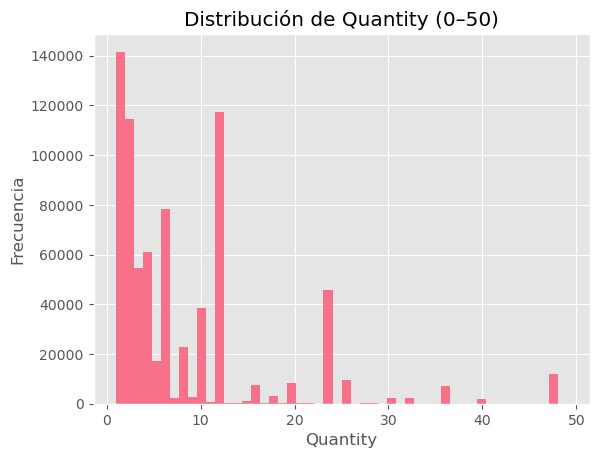

In [12]:
# Se analiza la distribución de la cantidad de productos comprados (quantity), limitando el rango a valores entre 0 y 50 para evitar la influencia de outliers.
# Se observa que la mayoría de compras son de pocas unidades, con picos en valores concretos que podrían corresponder a patrones de compra habituales (por ejemplo, packs).
plt.hist(df[(df["quantity"] > 0) & (df["quantity"] < 50)]["quantity"], bins=50)
plt.title("Distribución de Quantity (0–50)")
plt.xlabel("Quantity")
plt.ylabel("Frecuencia")
plt.show()

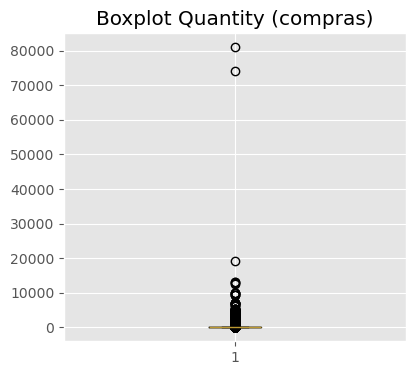

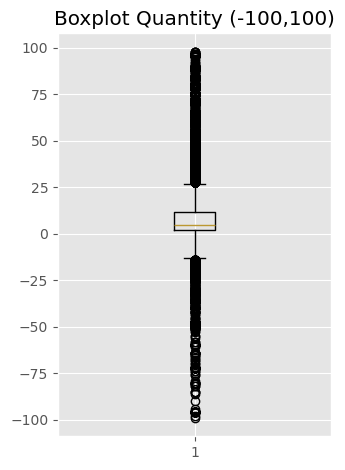

In [13]:
plt.figure(figsize=(15, 4))

# 1️⃣ Histogram Quantity (recortado)
plt.subplot(1, 3, 1)
plt.boxplot(df[df["quantity"] > 0]["quantity"])
plt.title("Boxplot Quantity (compras)")
plt.show()


# 3️⃣ Boxplot Quantity (recortado)
plt.subplot(1, 2, 1)
plt.boxplot(df[(df["quantity"] > -100) & (df["quantity"] < 100)]["quantity"])
plt.title("Boxplot Quantity (-100,100)")

plt.tight_layout()
plt.show()

-   La distribución de la variable quantity (limitada al rango 0–50) muestra que la mayoría de las compras se concentran en valores bajos, principalmente entre 1 y 10 unidades. Se observan picos en valores específicos como 1, 2 o 12, lo que sugiere patrones de compra recurrentes, posiblemente asociados a tamaños de pack o hábitos de consumo.

-   Asimismo, la distribución presenta una cola larga, indicando la existencia de compras de mayor volumen, aunque menos frecuentes. En conjunto, se trata de una distribución asimétrica típica en datos de retail.

---

## ***Distribución de 'price'***

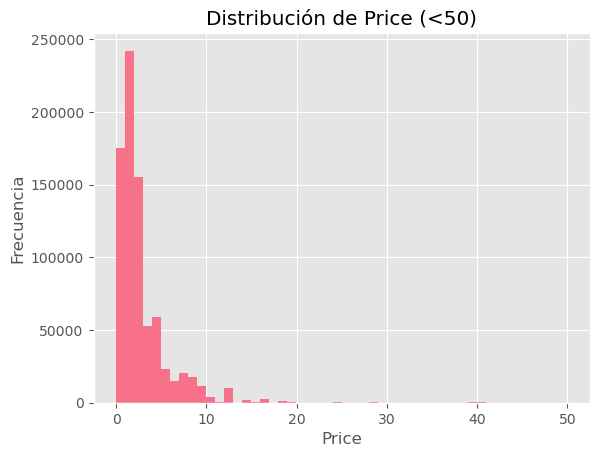

In [14]:
# Se analiza la distribución del precio de los productos, limitando el rango a valores menores de 50 para evitar la influencia de outliers. Se observa que la mayoría de los productos tienen precios bajos, con una distribución sesgada hacia la derecha, típica en datasets de retail.
plt.hist(df[df["price"] < 50]["price"], bins=50)
plt.title("Distribución de Price (<50)")
plt.xlabel("Price")
plt.ylabel("Frecuencia")
plt.show()

-   La distribución de la variable price muestra una fuerte concentración en valores bajos, con la mayoría de los productos situados en un rango inferior a 5 unidades monetarias. 

-   La distribución presenta una clara asimetría positiva, con una cola larga hacia valores más altos, lo que indica la existencia de productos más caros aunque menos frecuentes. Este comportamiento es típico en datasets de retail, donde predominan productos de bajo coste y alta rotación.

---

## ***Distribución por paises***

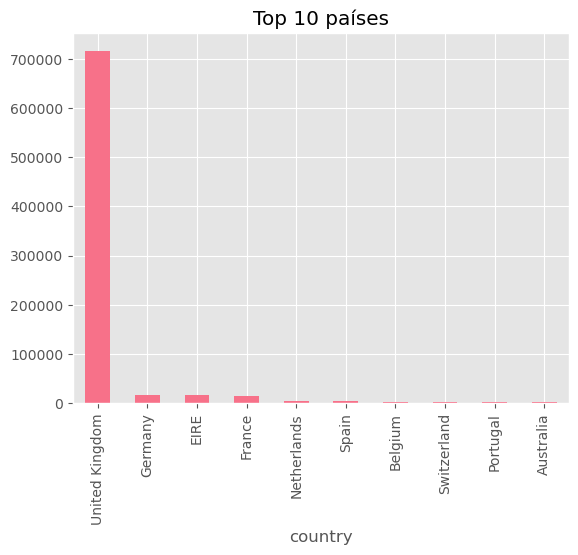

In [15]:
# Se analiza la distribución de las transacciones por país.
# Se observa un claro predominio del Reino Unido, lo que indica un fuerte desbalance geográfico en el dataset.
df["country"].value_counts().head(10).plot(kind="bar")
plt.title("Top 10 países")
plt.show()

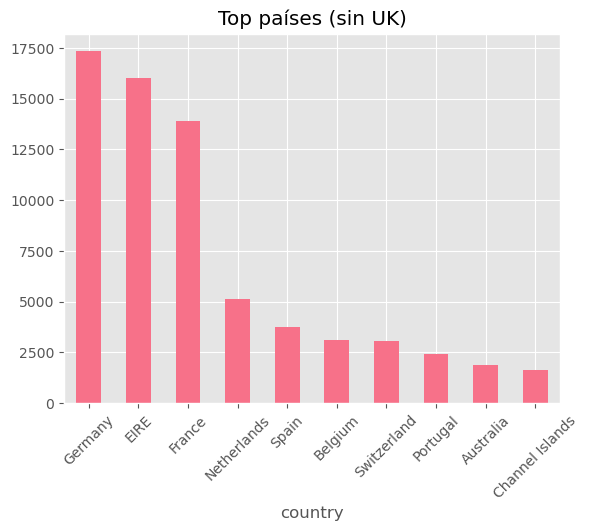

In [16]:
# El mismo sin UK
df_no_uk = df[df["country"] != "United Kingdom"]

df_no_uk["country"].value_counts().head(10).plot(kind="bar")
plt.title("Top países (sin UK)")
plt.xticks(rotation=45)
plt.show()

-   La distribución de las transacciones por país muestra un claro predominio del Reino Unido, concentrando la mayor parte de las operaciones. El resto de países presentan una representación significativamente menor.

-   Este desbalance geográfico sugiere que el comportamiento de los clientes está fuertemente influenciado por el mercado principal, lo que podría afectar la capacidad de generalización del modelo a otros países.

---

## ***Distribución de compras por cliente***

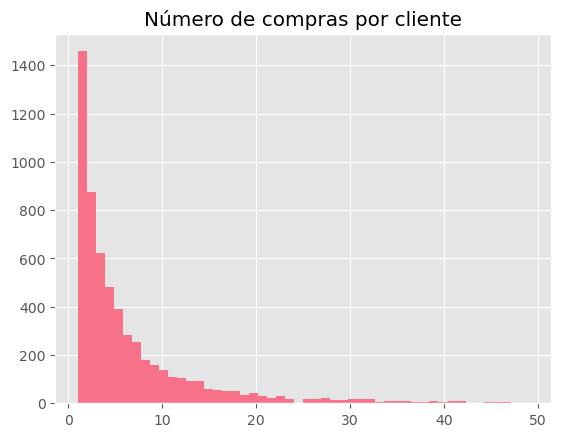

In [17]:
# Se calcula el número de compras por cliente (frecuencia), contando el número de facturas distintas por cada cliente.
# Se observa la distribución de compras, limitando el rango a valores menores de 50 para evitar la influencia de outliers.
customer_purchases = df.groupby("customer_id")["invoice"].nunique()

plt.hist(customer_purchases[customer_purchases < 50], bins=50)
plt.title("Número de compras por cliente")
plt.show()

-   La distribución del número de compras por cliente muestra que la mayoría de los clientes realizan pocas compras, principalmente entre 1 y 5 transacciones.
-   Se observa una distribución fuertemente asimétrica, con una cola larga que indica la existencia de un pequeño grupo de clientes altamente activos. Este comportamiento es típico en entornos de retail y sugiere la presencia de clientes ocasionales frente a clientes recurrentes o fieles.
-   Esta variable resulta especialmente relevante para el modelo, ya que la frecuencia de compra es un factor clave en la predicción de recompra.

---

## ***Distribución de devoluciones***

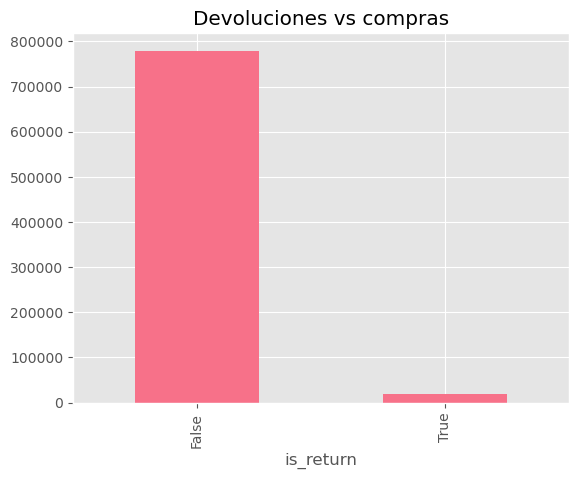

In [18]:
# Se analiza la proporción de devoluciones frente a compras.
# Se observa que la gran mayoría de transacciones corresponden a compras, mientras que las devoluciones representan una pequeña parte del total.
df["is_return"].value_counts().plot(kind="bar")
plt.title("Devoluciones vs compras")
plt.show()

-   La distribución de la variable is_return muestra que la mayoría de las transacciones corresponden a compras, mientras que las devoluciones representan una proporción reducida del total.
-   Aunque las devoluciones son poco frecuentes, constituyen un indicador relevante del comportamiento del cliente y han sido consideradas en el proceso de feature engineering mediante variables como el número de devoluciones y su proporción.

---

# ***6. CutOff temporal***

In [19]:
# Obtenemos la fecha más reciente del dataset.
# Esta fecha marca el final del histórico disponible y servirá como referencia para construir la ventana temporal del problema.
max_date = df["invoice_date"].max()
max_date

Timestamp('2011-12-09 12:50:00')

In [20]:
# Definimos la fecha de corte restando 3 meses a la fecha máxima del dataset.
# De este modo, los últimos 3 meses se reservarán para comprobar si el cliente recompra o no, mientras que el periodo anterior se usará para construir las variables predictoras.
cutoff_date = max_date - DateOffset(months=3)
cutoff_date

Timestamp('2011-09-09 12:50:00')

In [21]:
# Dividimos el dataset en dos subconjuntos temporales:
# - df_past: contiene las transacciones ocurridas hasta la fecha de corte
# - df_future: contiene las transacciones posteriores a la fecha de corte
# Esta separación es fundamental para evitar data leakage, ya que el modelo solo debe aprender a partir de información pasada.
df_past = df[df["invoice_date"] <= cutoff_date].copy()
df_future = df[df["invoice_date"] > cutoff_date].copy()

In [22]:
# Comprobación de los ultimos registros del df del pasado
df_past.tail(3)

,invoice,stock_code,description,quantity,invoice_date,price,customer_id,country,is_return,quantity_pos,quantity_neg,total_price,year,month,day,day_of_week,hour
635123,566178,22670,FRENCH WC SIGN BLUE METAL,24,2011-09-09 12:41:00,1.25,16353,United Kingdom,False,24,0,30.0,2011,9,9,4,12
635124,566178,21218,RED SPOTTY BISCUIT TIN,12,2011-09-09 12:41:00,3.75,16353,United Kingdom,False,12,0,45.0,2011,9,9,4,12
635125,566178,23574,PACKING CHARGE,1,2011-09-09 12:41:00,7.50,16353,United Kingdom,False,1,0,7.5,2011,9,9,4,12


In [23]:
# Comprobación de los primeros registros del df del futuro
df_future.head(3)

,invoice,stock_code,description,quantity,invoice_date,price,customer_id,country,is_return,quantity_pos,quantity_neg,total_price,year,month,day,day_of_week,hour
635126,C566180,21314,SMALL GLASS HEART TRINKET POT,-1,2011-09-09 12:52:00,2.10,16173,United Kingdom,True,0,-1,-2.10,2011,9,9,4,12
635127,C566180,22800,ANTIQUE TALL SWIRLGLASS TRINKET POT,-1,2011-09-09 12:52:00,3.75,16173,United Kingdom,True,0,-1,-3.75,2011,9,9,4,12
635128,C566180,22798,ANTIQUE GLASS DRESSING TABLE POT,-2,2011-09-09 12:52:00,2.95,16173,United Kingdom,True,0,-2,-5.90,2011,9,9,4,12


# ***7. Agrupación por cliente (Customer ID)***

Por cada cliente: **suma de tickets en el año** (facturación total), **número de compras** (facturas distintas) y **ticket medio** por compra.

In [24]:
# Agrupamos las transacciones del periodo pasado a nivel cliente.
# El objetivo es transformar el dataset transaccional (múltiples filas por cliente) en un dataset analítico con una única fila por cliente.

# En esta agregación calculamos:
# - frequency: número de facturas distintas del cliente (frecuencia de compra)
# - monetary: gasto total acumulado
# - avg_ticket: media de total_price por linea, no por factura completa
# - total_quantity: cantidad total comprada, excluyendo devoluciones
# - n_products: número de productos distintos adquiridos
# - n_returns: número de devoluciones registradas

features = df_past.groupby("customer_id").agg(
    frequency=("invoice", "nunique"),
    monetary=("total_price", "sum"),
    avg_ticket=("total_price", "mean"),
    total_quantity=("quantity_pos", "sum"),
    n_products=("stock_code", "nunique"),
    n_returns=("is_return", "sum")
)

In [25]:
# Calculamos la recencia (recency), el número de días transcurridos desde la última compra del cliente hasta la fecha de referencia del periodo pasado.
# Esta variable es especialmente relevante en problemas de recompra, ya que clientes que han comprado recientemente suelen tener mayor probabilidad de volver a comprar.

reference_date = df_past["invoice_date"].max()

recency = df_past.groupby("customer_id")["invoice_date"].max()
recency = (reference_date - recency).dt.days

features["recency"] = recency

In [26]:
# Calculamos la tasa de devoluciones de cada cliente como el cociente entre el número de devoluciones registradas y la frecuencia de compra.
# Esta variable permite capturar el peso relativo de las devoluciones en el comportamiento del cliente.

features["return_rate"] = features["n_returns"] / features["frequency"]
features["return_rate"] = features["return_rate"].fillna(0)

In [27]:
# Construimos la variable objetivo utilizando únicamente el periodo futuro.
# Para cada cliente, comprobamos si realiza al menos una compra después de la fecha de corte:
# - target = 1: el cliente vuelve a comprar
# - target = 0: el cliente no vuelve a comprar

target = df_future.groupby("customer_id")["invoice"].nunique()
target = (target > 0).astype(int)
target.name = "target"

In [28]:
# Unimos las variables explicativas con la variable objetivo.
# Se utiliza un left join para conservar todos los clientes del periodo pasado.
# Aquellos clientes que no aparecen en el periodo futuro reciben target = 0, ya que no han recompado en la ventana temporal definida.

df_model = features.merge(target, on="customer_id", how="left")
df_model["target"] = df_model["target"].fillna(0).astype(int)

In [29]:
# Realizamos una comprobación final del dataset de modelado:
# - primeras filas, para revisar la estructura
# - dimensiones, para conocer el número total de clientes
# - distribución de la variable objetivo, para detectar posibles desbalances
# - valores nulos, para asegurar que el dataset está listo para entrenar modelos

display(df_model.head())
display(f"Dimensiones: {df_model.shape}")
print("Conteo de la variable target")
display(df_model["target"].value_counts())
print("Verificación de nulos")
df_model.isna().sum()

,frequency,monetary,avg_ticket,total_quantity,n_products,n_returns,recency,return_rate,target
customer_id,,,,,,,,,
12346,17,-51.74,-1.100851,74285,30,13,234,0.764706,0
12347,6,3402.39,20.746280,2099,107,0,38,0.000000,1
12348,4,1709.40,35.612500,2497,25,0,157,0.000000,1
12349,4,2646.99,24.738224,993,92,5,316,1.250000,1
12350,1,334.40,19.670588,197,17,0,218,0.000000,0


'Dimensiones: (5342, 9)'

Conteo de la variable target


target
0    3018
1    2324
Name: count, dtype: int64

Verificación de nulos


frequency         0
monetary          0
avg_ticket        0
total_quantity    0
n_products        0
n_returns         0
recency           0
return_rate       0
target            0
dtype: int64

# ***8. Modelo: probabilidad de recompra***

Modelo supervisado para estimar la probabilidad de que un cliente **vuelva a comprar** después de una fecha de corte.

Estrategia:
- Definimos una **fecha de corte** (`cutoff_date`).
- Con los datos **antes** de esa fecha construimos variables por cliente (RFM simplificado: recencia, frecuencia, gasto total, ticket medio, país, etc.).
- Con los datos **después** de la fecha etiquetamos si el cliente **recompró (1)** o **no recompró (0)**.
- Entrenamos una **regresión logística** para predecir esa probabilidad de recompra.

### (Opcional) Búsqueda de hiperparámetros
randomsearch, gridsearch, optuna, 


In [30]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, roc_auc_score
from sklearn.model_selection import train_test_split

In [31]:
# X contiene las variables predictoras (features)
# Eliminamos la columna target porque es lo que queremos predecir
X = df_model.drop(columns=["target"])          

# y contiene la variable objetivo
# 1 = recompra, 0 = no recompra
y = df_model["target"]          

-   X : lo que el modelo usa para aprender  
-   y : lo que el modelo intenta predecir

In [32]:
# Dividimos los datos en entrenamiento (80%) y test (20%)
X_train, X_test, y_train, y_test = train_test_split(
    X, y,               # datos
    test_size=0.2,      # 20% para test
    random_state=42,    # para reproducibilidad (siempre misma división)
    stratify=y          # mantiene proporción de clases (0 y 1)
)

In [33]:
# Creamos el objeto scaler
scaler = StandardScaler()

# Ajustamos el scaler solo con train y transformamos
X_train_scaled = scaler.fit_transform(X_train)

# Transformamos test con los mismos parámetros
X_test_scaled = scaler.transform(X_test)

In [34]:
# Creamos el modelo de regresión logística
model = LogisticRegression(max_iter=1000, random_state=42)

# Entrenamos el modelo con los datos de entrenamiento
model.fit(X_train_scaled, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,42
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [35]:
# Predicción de clases (0 o 1)
y_pred = model.predict(X_test_scaled)

# Predicción de clases (0 o 1)
y_prob = model.predict_proba(X_test_scaled)[:, 1]

# Mostramos las métricas de clasificación (precision, recall y f1-score)
print(classification_report(y_test, y_pred))

# Mostramos el calculo del ROC-AUC
print("ROC-AUC:", roc_auc_score(y_test, y_prob))

              precision    recall  f1-score   support

           0       0.76      0.82      0.79       604
           1       0.74      0.66      0.70       465

    accuracy                           0.75      1069
   macro avg       0.75      0.74      0.74      1069
weighted avg       0.75      0.75      0.75      1069

ROC-AUC: 0.8084526098412019


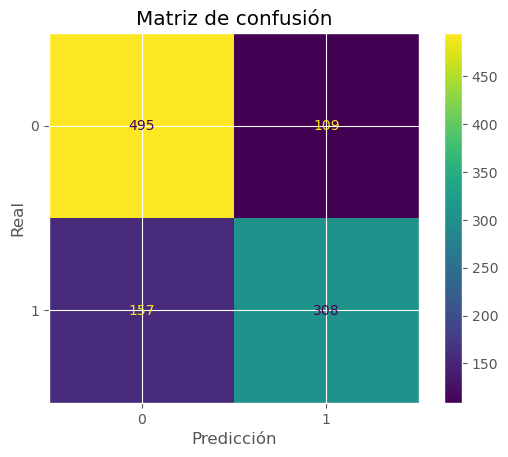

In [36]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Calculamos la matriz de confusión
cm = confusion_matrix(y_test, y_pred)

# Representación gráfica
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.title("Matriz de confusión")
plt.ylabel("Real")
plt.xlabel("Predicción")
plt.show()

El ROC-AUC mide que tan bien separa el modelo de las clases, en este caso lo hace bastante bien con una media de 0.808.

Posteriormente trataré de optimizar los hiperparámetros para mejorar el rendimiento del modelo y asi sacar mejores resultados

- Para la clase **0 (no recompra)**:
  - **Precision: 0.76** → cuando el modelo predice que un cliente no recompra, acierta en el 76% de los casos.
  - **Recall: 0.82** → el modelo identifica correctamente el 82% de los clientes que realmente no recompran.
  - Esto indica que el modelo es bastante bueno detectando clientes que no volverán a comprar.

- Para la clase **1 (recompra)**:
  - **Precision: 0.74** → cuando predice recompra, acierta en el 74% de los casos.
  - **Recall: 0.66** → solo detecta el 66% de los clientes que realmente recompran.
  - Esto sugiere que el modelo tiene más dificultad en identificar a los clientes que sí volverán a comprar.

El **F1-score** es equilibrado entre ambas clases (~0.70–0.79), lo que indica un buen compromiso entre precisión y recall.
El modelo obtiene una **accuracy del 75%**, lo que indica que clasifica correctamente aproximadamente tres de cada cuatro clientes.

### ***Conclusión***

En conjunto, el modelo muestra un rendimiento satisfactorio como baseline. Destaca especialmente en la identificación de clientes que no recompran, aunque existe margen de mejora en la detección de clientes que sí vuelven a comprar.

---

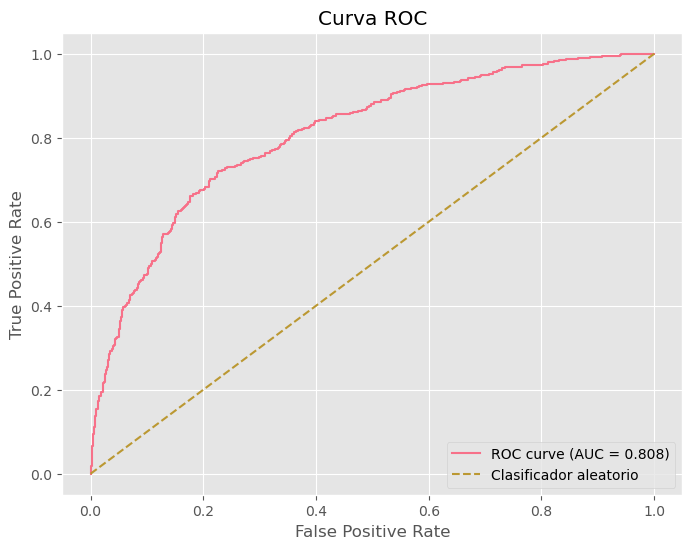

In [37]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Obtenemos las probabilidades de la clase positiva (recompra = 1)
y_prob = model.predict_proba(X_test_scaled)[:, 1]

# Calculamos la curva ROC
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

# Calculamos el área bajo la curva (AUC)
roc_auc = auc(fpr, tpr)

# Gráfico
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f"ROC curve (AUC = {roc_auc:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--", label="Clasificador aleatorio")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Curva ROC")
plt.legend(loc="lower right")
plt.show()

## ***Comparación con otros modelos afines*** 

In [38]:
# Creo un modelo Random Forest.
# Este modelo está basado en múltiples árboles de decisión y combina sus resultados para obtener una predicción más robusta.
rf = RandomForestClassifier(random_state=42)

# Entrenamos el modelo con los datos de entrenamiento.
rf.fit(X_train, y_train)

# Obtenemos la probabilidad estimada de la clase positiva (recompra = 1) para cada cliente del conjunto de test.
y_prob_rf = rf.predict_proba(X_test)[:, 1]

y_pred_rf = rf.predict(X_test)

print("\n=== Random Forest ===")
print(classification_report(y_test, y_pred_rf))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_rf))


=== Random Forest ===
              precision    recall  f1-score   support

           0       0.73      0.80      0.76       604
           1       0.70      0.62      0.66       465

    accuracy                           0.72      1069
   macro avg       0.72      0.71      0.71      1069
weighted avg       0.72      0.72      0.72      1069

ROC-AUC: 0.7814783165990172


In [39]:
# Creo un modelo XGBoost.
# Es un modelo de boosting que construye árboles secuencialmente, corrigiendo los errores del árbol anterior.
xgb = XGBClassifier(random_state=42)

xgb.fit(X_train, y_train)

y_prob_xgb = xgb.predict_proba(X_test)[:, 1]

y_pred_xgb = xgb.predict(X_test)

print("\n=== XGBoost ===")
print(classification_report(y_test, y_pred_xgb))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_xgb))


=== XGBoost ===
              precision    recall  f1-score   support

           0       0.72      0.78      0.75       604
           1       0.68      0.61      0.64       465

    accuracy                           0.70      1069
   macro avg       0.70      0.69      0.69      1069
weighted avg       0.70      0.70      0.70      1069

ROC-AUC: 0.771772413302001


In [40]:
# Creamos un modelo LightGBM.
# Modelo de boosting basado en árboles, diseñado para ser rápido y eficiente.
lgbm = LGBMClassifier(random_state=42)

lgbm.fit(X_train, y_train)

y_prob_lgbm = lgbm.predict_proba(X_test)[:, 1]

y_pred_lgbm = lgbm.predict(X_test)

print("\n=== LightGBM ===")
print(classification_report(y_test, y_pred_lgbm))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_lgbm))

[LightGBM] [Info] Number of positive: 1859, number of negative: 2414
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000564 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1614
[LightGBM] [Info] Number of data points in the train set: 4273, number of used features: 8
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.435057 -> initscore=-0.261246
[LightGBM] [Info] Start training from score -0.261246

=== LightGBM ===
              precision    recall  f1-score   support

           0       0.74      0.82      0.78       604
           1       0.73      0.62      0.67       465

    accuracy                           0.73      1069
   macro avg       0.73      0.72      0.72      1069
weighted avg       0.73      0.73      0.73      1069

ROC-AUC: 0.794292530086164


In [41]:
# Imprimimos el valor de ROC-AUC de cada modelo para compararlos directamente.
print("Logistic:", roc_auc_score(y_test, y_prob))
print("RF:", roc_auc_score(y_test, y_prob_rf))
print("XGB:", roc_auc_score(y_test, y_prob_xgb))

Logistic: 0.8084526098412019
RF: 0.7814783165990172
XGB: 0.771772413302001


In [42]:
# Logistic
fpr_log, tpr_log, _ = roc_curve(y_test, y_prob)
auc_log = auc(fpr_log, tpr_log)

# Random Forest
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)
auc_rf = auc(fpr_rf, tpr_rf)

# XGBoost
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, y_prob_xgb)
auc_xgb = auc(fpr_xgb, tpr_xgb)

#LightGBM
fpr_lgbm, tpr_lgbm, _ = roc_curve(y_test, y_prob_lgbm)
auc_lgbm = auc(fpr_lgbm, tpr_lgbm)

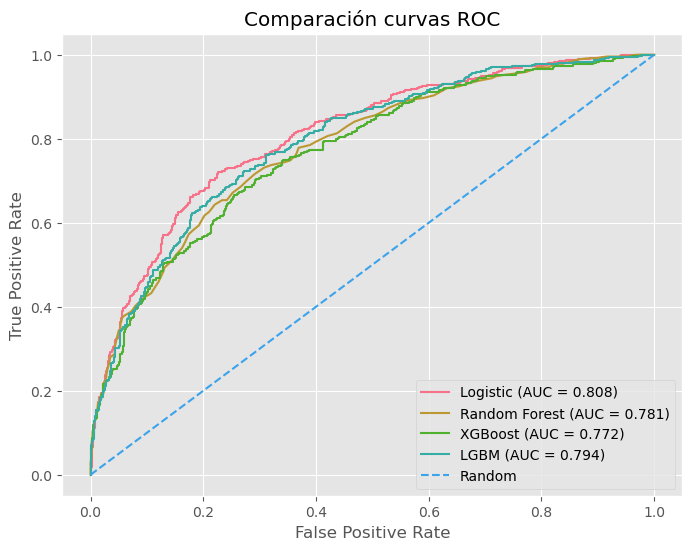

Logistic AUC: 0.808
RF AUC: 0.781
XGB AUC: 0.772
LGBM AUC: 0.794


In [43]:
# Aquí creo una grafica conjunta para mostrar las curvas ROC juntas y compararlas visualmente
plt.figure(figsize=(8,6))

plt.plot(fpr_log, tpr_log, label=f"Logistic (AUC = {auc_log:.3f})")
plt.plot(fpr_rf, tpr_rf, label=f"Random Forest (AUC = {auc_rf:.3f})")
plt.plot(fpr_xgb, tpr_xgb, label=f"XGBoost (AUC = {auc_xgb:.3f})")
plt.plot(fpr_lgbm, tpr_lgbm, label=f"LGBM (AUC = {auc_lgbm:.3f})")

# línea base
plt.plot([0, 1], [0, 1], linestyle="--", label="Random")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Comparación curvas ROC")
plt.legend(loc="lower right")

plt.show()
print(f"Logistic AUC: {auc_log:.3f}")
print(f"RF AUC: {auc_rf:.3f}")
print(f"XGB AUC: {auc_xgb:.3f}")
print(f"LGBM AUC: {auc_lgbm:.3f}")

## ***Conclusión***
Después de comparar los resultados de los diferentes modelos, nos quedaremos con la regresión logística ya que demuestra una ROC-AUC mejor que el resto junto a un classification_report mejor.

---

# ***9. Optimización de hiperparamtros***

In [44]:
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression

# Definimos la rejilla de hiperparámetros que queremos probar.
# GridSearchCV evaluará todas las combinaciones posibles de estos valores.
param_grid_log = {
    "C": [0.01, 0.1, 1, 10, 100],       # intensidad de la regularización
    "penalty": ["l2"],                  # tipo de regularización
    "solver": ["lbfgs"]                 # tipo de regularización
}

# Creamos el modelo base de regresión logística.
# Este modelo será entrenado varias veces con distintas combinaciones de hiperparámetros.
log = LogisticRegression(max_iter=1000, random_state=42)

# Se probarán todas las combinaciones posibles de la rejilla definida arriba.
grid_log = GridSearchCV(
    log,                    # modelo que queremos optimizar
    param_grid_log,         # hiperparámetros a probar
    cv=5,
    scoring="roc_auc",      # validación cruzada con 5 particiones
    n_jobs=-1
)

# Ejecutamos la búsqueda de hiperparámetros sobre los datos de entrenamiento.
# Como la regresión logística necesita variables escaladas, utilizamos X_train_scaled.
grid_log.fit(X_train_scaled, y_train)

# Recuperamos el mejor modelo encontrado por la búsqueda.
best_log = grid_log.best_estimator_

# Mostramos la mejor combinación de hiperparámetros encontrada y su mejor resultado medio en validación cruzada.
print(grid_log.best_params_)
print(grid_log.best_score_)

{'C': 0.1, 'penalty': 'l2', 'solver': 'lbfgs'}
0.7947486479242858


In [45]:
from lightgbm import LGBMClassifier

#Haré lo mismo que la celda anterior pero ahora con ligthgbm

# Definimos la rejilla de hiperparámetros para LightGBM.
param_grid_lgbm = {
    "n_estimators": [100, 200],         # número de árboles
    "learning_rate": [0.01, 0.1],       # ritmo de aprendizaje
    "max_depth": [-1, 5, 10],           # profundidad máxima de los árboles
    "num_leaves": [31, 50]              # número máximo de hojas por árbol
}

#Creo el modelo base de LightGBM
lgbm = LGBMClassifier(random_state=42)

# Configuramos la búsqueda en rejilla para LightGBM. Es igual que para la regresión logística peroo adaptando algun parámetro
grid_lgbm = GridSearchCV(
    lgbm,
    param_grid_lgbm,
    cv=3,
    scoring="roc_auc",
    n_jobs=-1
)

# Ejecutamos la búsqueda sobre los datos de entrenamiento.
grid_lgbm.fit(X_train, y_train)

# Recuperamos el mejor modelo encontrado.
best_lgbm = grid_lgbm.best_estimator_

# Volvemos a mostrar la mejor combinación de hiperparámetros encontrados
print(grid_lgbm.best_params_)
print(grid_lgbm.best_score_)

[LightGBM] [Info] Number of positive: 1859, number of negative: 2414
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000281 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1614
[LightGBM] [Info] Number of data points in the train set: 4273, number of used features: 8
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.435057 -> initscore=-0.261246
[LightGBM] [Info] Start training from score -0.261246
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, b

In [46]:
# Logistic optimizada
y_prob_log_opt = best_log.predict_proba(X_test_scaled)[:, 1]

# LGBM optimizado
y_prob_lgbm_opt = best_lgbm.predict_proba(X_test)[:, 1]

print("Logistic OPT:", roc_auc_score(y_test, y_prob_log_opt))
print("LGBM OPT:", roc_auc_score(y_test, y_prob_lgbm_opt))

Logistic OPT: 0.8084953357544685
LGBM OPT: 0.8046108381399987


### ***Optimización de hiperparámetros***

Con el fin de mejorar el rendimiento de los modelos, se aplicó una búsqueda de hiperparámetros mediante **GridSearchCV** sobre la regresión logística y LightGBM.

En el caso de la regresión logística, se ajustó principalmente el parámetro de regularización `C`, manteniendo la penalización `l2` y el solver `lbfgs`. Para LightGBM, se exploraron combinaciones relacionadas con el número de árboles, la tasa de aprendizaje, la profundidad y el número de hojas.

La selección de la mejor configuración se realizó utilizando **validación cruzada** y optimizando la métrica **ROC-AUC**, dado que esta ofrece una medida robusta de la capacidad de discriminación del modelo.

---

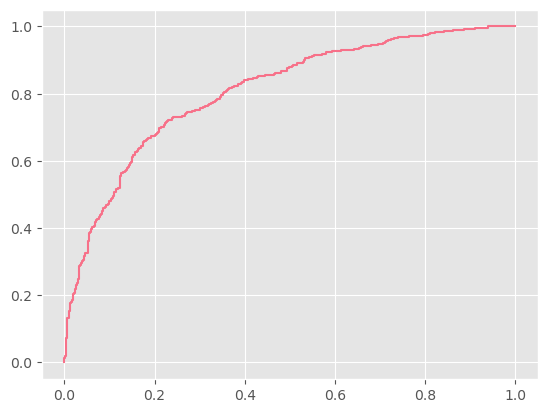

In [47]:
fpr_log_opt, tpr_log_opt, _ = roc_curve(y_test, y_prob_log_opt)
auc_log_opt = auc(fpr_log_opt, tpr_log_opt)

plt.plot(fpr_log_opt, tpr_log_opt, label=f"Logistic OPT (AUC = {auc_log_opt:.3f})")

## ***9.5 FEATURE ENGINEERING ADICIONAL + LIGHTGBM CON OPTUNA***

Dimensión del nuevo dataset de modelado: (5342, 15)


,frequency,monetary,total_quantity,n_products,n_returns,recency,customer_age_days,active_months,main_country,avg_ticket_real,max_ticket,avg_distinct_products_per_invoice,avg_days_between_purchases,return_rate,target
customer_id,,,,,,,,,,,,,,,
12346,17,-51.74,74285,30,13,234,634,6,United Kingdom,-3.043529,77183.60,2.294118,24.562500,0.764706,0
12347,6,3402.39,2099,107,0,38,312,6,Iceland,567.065000,711.79,27.333333,54.400000,0.000000,1
12348,4,1709.40,2497,25,0,157,346,4,Finland,427.350000,892.80,11.000000,63.000000,0.000000,1
12349,4,2646.99,993,92,5,316,643,4,Italy,661.747500,1402.62,26.750000,108.666667,1.250000,1
12350,1,334.40,197,17,0,218,218,1,Norway,334.400000,334.40,17.000000,0.000000,0.000000,0


target
0    3018
1    2324
Name: count, dtype: int64

frequency                            0
monetary                             0
total_quantity                       0
n_products                           0
n_returns                            0
recency                              0
customer_age_days                    0
active_months                        0
main_country                         0
avg_ticket_real                      0
max_ticket                           0
avg_distinct_products_per_invoice    0
avg_days_between_purchases           0
return_rate                          0
target                               0
dtype: int64

[I 2026-03-26 12:43:12,316] A new study created in memory with name: no-name-d5f61991-bb21-4e5f-9717-0e7b71f4c978


[LightGBM] [Info] Number of positive: 1859, number of negative: 2414
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000721 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2669
[LightGBM] [Info] Number of data points in the train set: 4273, number of used features: 14
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.435057 -> initscore=-0.261246
[LightGBM] [Info] Start training from score -0.261246
LightGBM base con nuevas features - ROC-AUC: 0.8006266467279071


[I 2026-03-26 12:43:15,198] Trial 0 finished with value: 0.7954473797716896 and parameters: {'n_estimators': 542, 'learning_rate': 0.025459455566321915, 'num_leaves': 118, 'max_depth': 11, 'min_child_samples': 63, 'subsample': 0.8766179498333768, 'colsample_bytree': 0.665916817925748, 'reg_alpha': 0.22596188556726565, 'reg_lambda': 9.568853986214524}. Best is trial 0 with value: 0.7954473797716896.
[I 2026-03-26 12:43:15,546] Trial 1 finished with value: 0.8054955912231417 and parameters: {'n_estimators': 143, 'learning_rate': 0.05081086934130948, 'num_leaves': 121, 'max_depth': 4, 'min_child_samples': 54, 'subsample': 0.6643675036193702, 'colsample_bytree': 0.828718722234899, 'reg_alpha': 0.00018996353579977916, 'reg_lambda': 0.0035264324150400903}. Best is trial 1 with value: 0.8054955912231417.
[I 2026-03-26 12:43:18,302] Trial 2 finished with value: 0.767286318965792 and parameters: {'n_estimators': 606, 'learning_rate': 0.12790200745807015, 'num_leaves': 74, 'max_depth': 10, 'min_

Mejor ROC-AUC medio en validación cruzada: 0.8097405520417913
Mejores hiperparámetros encontrados:
{'n_estimators': 392, 'learning_rate': 0.015673150685535667, 'num_leaves': 79, 'max_depth': 3, 'min_child_samples': 40, 'subsample': 0.9357818054633678, 'colsample_bytree': 0.6625145259113824, 'reg_alpha': 0.2003535899155529, 'reg_lambda': 0.003184969203780287}
[LightGBM] [Info] Number of positive: 1859, number of negative: 2414
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000461 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2669
[LightGBM] [Info] Number of data points in the train set: 4273, number of used features: 14
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.435057 -> initscore=-0.261246
[LightGBM] [Info] Start training from score -0.261246
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -in

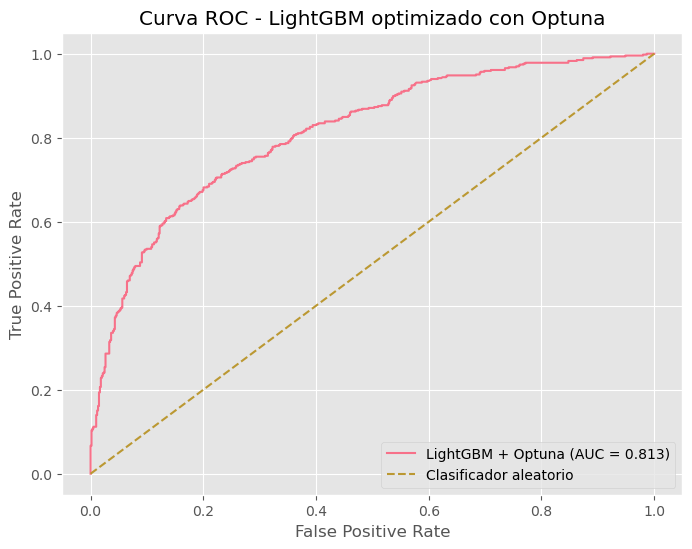

,feature,importance
5,recency,455
12,avg_days_between_purchases,337
1,monetary,231
6,customer_age_days,224
9,avg_ticket_real,188
7,active_months,180
10,max_ticket,152
2,total_quantity,151
11,avg_distinct_products_per_invoice,141
0,frequency,134


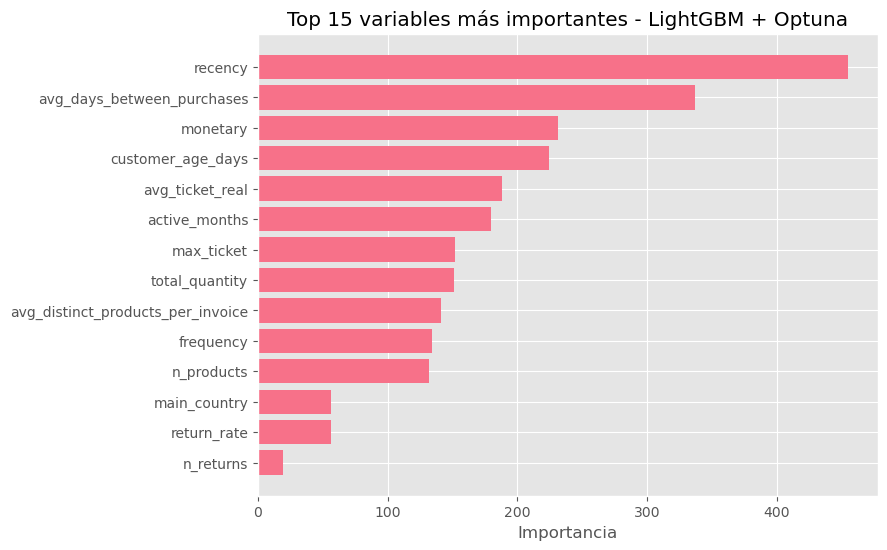

Dataset optimizado listo para scoring: (5342, 15)


In [50]:
import optuna
from lightgbm import LGBMClassifier
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.metrics import classification_report, roc_auc_score, roc_curve, auc
import matplotlib.pyplot as plt

# 1. RECONSTRUCCIÓN DE FEATURES MÁS RICAS A NIVEL CLIENTE

# Volvemos a partir de df_past y df_future para construir un nuevo dataset de modelado con variables adicionales.

# 1.1 Fecha de referencia

# Usamos la última fecha disponible en el periodo pasado como referencia para calcular variables temporales como recency o antigüedad del cliente.
reference_date = df_past["invoice_date"].max()

# 1.2 Features base por cliente

# Agregamos la información transaccional a nivel cliente.
# Cada fila del nuevo dataset representará un cliente.
features_opt = df_past.groupby("customer_id").agg(
    frequency=("invoice", "nunique"),          # Número de facturas distintas
    monetary=("total_price", "sum"),           # Gasto total acumulado
    total_quantity=("quantity_pos", "sum"),    # Cantidad total comprada (sin devoluciones)
    n_products=("stock_code", "nunique"),      # Número de productos distintos comprados
    n_returns=("is_return", "sum")             # Número de devoluciones
)

# 1.3 Recency

# Recency = días desde la última compra del cliente hasta la fecha de referencia del periodo pasado.
last_purchase = df_past.groupby("customer_id")["invoice_date"].max()
features_opt["recency"] = (reference_date - last_purchase).dt.days

# 1.4 Antigüedad del cliente

# customer_age_days = días desde la primera compra del cliente hasta la fecha de referencia.
first_purchase = df_past.groupby("customer_id")["invoice_date"].min()
features_opt["customer_age_days"] = (reference_date - first_purchase).dt.days

# 1.5 Meses activos

# Creamos una variable temporal año-mes y contamos en cuántos meses distintos estuvo activo cada cliente.
df_past_tmp = df_past.copy()
df_past_tmp["year_month"] = df_past_tmp["invoice_date"].dt.to_period("M")

features_opt["active_months"] = df_past_tmp.groupby("customer_id")["year_month"].nunique()

# 1.6 País principal del cliente

# Para cada cliente tomamos el país más frecuente (moda).
# Esto nos permite incorporar una variable categórica de contexto geográfico.
main_country = df_past.groupby("customer_id")["country"].agg(
    lambda x: x.mode().iloc[0] if not x.mode().empty else x.iloc[0]
)
features_opt["main_country"] = main_country

# 1.7 Variables a nivel factura (ticket real)

# Hasta ahora el "avg_ticket" que teníamos era media por línea.
# Aquí calculamos el ticket real por factura agregando primero a nivel invoice.
invoice_level = (
    df_past.groupby(["customer_id", "invoice"])
    .agg(
        invoice_total=("total_price", "sum"),          # total de la factura
        invoice_products=("stock_code", "nunique"),    # nº productos distintos en la factura
        invoice_date=("invoice_date", "min")           # fecha de la factura
    )
    .reset_index()
)

# 1.8 Ticket medio real y ticket máximo

# Calculamos para cada cliente:
# - avg_ticket_real: gasto medio por factura
# - max_ticket: factura de mayor importe
features_opt["avg_ticket_real"] = invoice_level.groupby("customer_id")["invoice_total"].mean()
features_opt["max_ticket"] = invoice_level.groupby("customer_id")["invoice_total"].max()


# 1.9 Número medio de productos distintos por factura

features_opt["avg_distinct_products_per_invoice"] = (
    invoice_level.groupby("customer_id")["invoice_products"].mean()
)

# 1.10 Tiempo medio entre compras

# Ordenamos las facturas por cliente y calculamos la diferencia entre fechas.
invoice_level_sorted = invoice_level.sort_values(["customer_id", "invoice_date"]).copy()

invoice_level_sorted["days_between_purchases"] = (
    invoice_level_sorted.groupby("customer_id")["invoice_date"].diff().dt.days
)

avg_days_between = invoice_level_sorted.groupby("customer_id")["days_between_purchases"].mean()
features_opt["avg_days_between_purchases"] = avg_days_between

# 1.11 Ratio de devoluciones

features_opt["return_rate"] = features_opt["n_returns"] / features_opt["frequency"]


# 1.12 Tratamiento de valores nulos generados por agregación

# Algunas variables como avg_days_between_purchases pueden quedar nulas en clientes con una sola compra. En ese caso usamos 0 como valor neutro.
features_opt["avg_days_between_purchases"] = features_opt["avg_days_between_purchases"].fillna(0)
features_opt["return_rate"] = features_opt["return_rate"].fillna(0)

# 1.13 Variable objetivo (target)

# Construimos el target con el periodo futuro:
# 1 -> el cliente recompra
# 0 -> no recompra
target_opt = df_future.groupby("customer_id")["invoice"].nunique()
target_opt = (target_opt > 0).astype(int)
target_opt.name = "target"

# 1.14 Unimos features y target

# Con un left join conservamos todos los clientes del periodo pasado.
# Si un cliente no aparece en el futuro, su target será 0.
df_model_opt = features_opt.merge(target_opt, on="customer_id", how="left")
df_model_opt["target"] = df_model_opt["target"].fillna(0).astype(int)

# 1.15 Conversión de variables categóricas

# LightGBM puede trabajar con variables categóricas si están tipadas como category.
df_model_opt["main_country"] = df_model_opt["main_country"].astype("category")

# 1.16 Comprobación rápida del nuevo dataset
print("Dimensión del nuevo dataset de modelado:", df_model_opt.shape)
display(df_model_opt.head())
display(df_model_opt["target"].value_counts())
display(df_model_opt.isna().sum())

# 2. PREPARACIÓN DE DATOS PARA LIGHTGBM

# Separamos variables predictoras (X) y variable objetivo (y)
X_opt = df_model_opt.drop(columns=["target"])
y_opt = df_model_opt["target"]

# Dividimos en train y test manteniendo la proporción de clases
X_train_opt, X_test_opt, y_train_opt, y_test_opt = train_test_split(
    X_opt,
    y_opt,
    test_size=0.2,
    random_state=42,
    stratify=y_opt
)


# 3. LIGHTGBM BASELINE CON NUEVAS FEATURES
# Antes de optimizar con Optuna, probamos un LightGBM base para ver si el nuevo feature engineering ya aporta mejora.

lgbm_base = LGBMClassifier(random_state=42)

# Entrenamos el modelo base
lgbm_base.fit(X_train_opt, y_train_opt)

# Probabilidades de la clase positiva (recompra = 1)
y_prob_lgbm_base = lgbm_base.predict_proba(X_test_opt)[:, 1]

# Evaluamos ROC-AUC
auc_lgbm_base = roc_auc_score(y_test_opt, y_prob_lgbm_base)
print("LightGBM base con nuevas features - ROC-AUC:", auc_lgbm_base)

# 4. OPTIMIZACIÓN DE HIPERPARÁMETROS CON OPTUNA
# Optuna busca automáticamente una buena combinación de parámetros
# maximizando la métrica ROC-AUC mediante validación cruzada.

def objective(trial):
    """
    Función objetivo para Optuna.
    En cada iteración (trial), Optuna propone un conjunto de hiperparámetros
    y evaluamos su rendimiento
    """
    
    params = {
        "objective": "binary",
        "metric": "auc",
        "boosting_type": "gbdt",
        "random_state": 42,
        
        # Número de árboles
        "n_estimators": trial.suggest_int("n_estimators", 100, 800),
        
        # Ritmo de aprendizaje
        "learning_rate": trial.suggest_float("learning_rate", 0.005, 0.2, log=True),
        
        # Complejidad del árbol
        "num_leaves": trial.suggest_int("num_leaves", 15, 150),
        "max_depth": trial.suggest_int("max_depth", 3, 12),
        
        # Mínimo nº de muestras por nodo hoja
        "min_child_samples": trial.suggest_int("min_child_samples", 5, 100),
        
        # Submuestreo de filas y columnas para robustez
        "subsample": trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),
        
        # Regularización
        "reg_alpha": trial.suggest_float("reg_alpha", 1e-4, 10.0, log=True),
        "reg_lambda": trial.suggest_float("reg_lambda", 1e-4, 10.0, log=True),
    }

    # Creamos el modelo con la configuración propuesta
    model = LGBMClassifier(**params)

    # Validación cruzada estratificada para una evaluación robusta
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

    # Calculamos el ROC-AUC medio en CV
    scores = cross_val_score(
        model,
        X_train_opt,
        y_train_opt,
        cv=cv,
        scoring="roc_auc",
        n_jobs=-1
    )

    # Optuna intentará maximizar esta media
    return scores.mean()


# Creamos el estudio de Optuna
study = optuna.create_study(direction="maximize")

# Ejecutamos la optimización
study.optimize(objective, n_trials=50)

# 4.1 Resultados de la optimización
print("Mejor ROC-AUC medio en validación cruzada:", study.best_trial.value)
print("Mejores hiperparámetros encontrados:")
print(study.best_trial.params)

# Recuperamos los mejores parámetros
best_params_optuna = study.best_trial.params

# Creamos el mejor modelo con esos parámetros
best_lgbm_optuna = LGBMClassifier(
    objective="binary",
    metric="auc",
    boosting_type="gbdt",
    random_state=42,
    **best_params_optuna
)

# Entrenamos el modelo final optimizado con todos los datos de train
best_lgbm_optuna.fit(X_train_opt, y_train_opt)

# Obtenemos predicciones de clase y probabilidades sobre test
y_pred_lgbm_optuna = best_lgbm_optuna.predict(X_test_opt)
y_prob_lgbm_optuna = best_lgbm_optuna.predict_proba(X_test_opt)[:, 1]


# 6. EVALUACIÓN FINAL DEL LIGHTGBM OPTIMIZADO
print("=== LightGBM + Optuna ===")
print(classification_report(y_test_opt, y_pred_lgbm_optuna))
print("ROC-AUC:", roc_auc_score(y_test_opt, y_prob_lgbm_optuna))


# 7. CURVA ROC DEL LIGHTGBM OPTIMIZADO
fpr_opt, tpr_opt, _ = roc_curve(y_test_opt, y_prob_lgbm_optuna)
auc_opt = auc(fpr_opt, tpr_opt)

plt.figure(figsize=(8, 6))
plt.plot(fpr_opt, tpr_opt, label=f"LightGBM + Optuna (AUC = {auc_opt:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--", label="Clasificador aleatorio")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Curva ROC - LightGBM optimizado con Optuna")
plt.legend(loc="lower right")
plt.show()

# Esto nos permite ver qué features son más relevantes en el nuevo modelo.
feat_importance_opt = pd.DataFrame({
    "feature": X_train_opt.columns,
    "importance": best_lgbm_optuna.feature_importances_
}).sort_values("importance", ascending=False)

display(feat_importance_opt.head(15))

plt.figure(figsize=(8, 6))
plt.barh(feat_importance_opt["feature"].head(15)[::-1],
         feat_importance_opt["importance"].head(15)[::-1])
plt.title("Top 15 variables más importantes - LightGBM + Optuna")
plt.xlabel("Importancia")
plt.show()


# Guardamos una copia del dataset optimizado 
df_model_opt_final = df_model_opt.copy()

print("Dataset optimizado listo para scoring:", df_model_opt_final.shape)

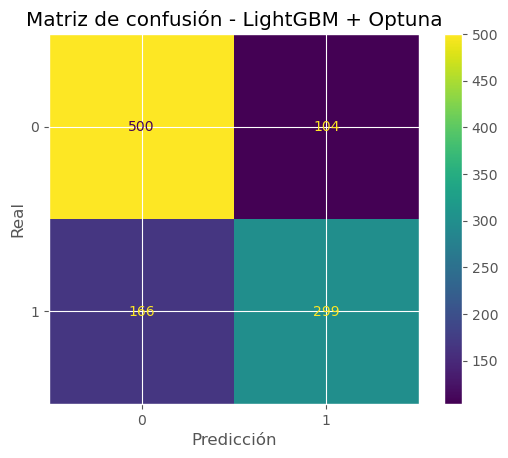

Accuracy: 0.7474275023386342

Classification Report:

              precision    recall  f1-score   support

           0       0.75      0.83      0.79       604
           1       0.74      0.64      0.69       465

    accuracy                           0.75      1069
   macro avg       0.75      0.74      0.74      1069
weighted avg       0.75      0.75      0.74      1069



In [52]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report, accuracy_score
# =========================================================
# MATRIZ DE CONFUSIÓN - LIGHTGBM + OPTUNA
# =========================================================

# Calculamos la matriz de confusión con las predicciones del modelo optimizado
cm = confusion_matrix(y_test_opt, y_pred_lgbm_optuna)

# Representación gráfica
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()

plt.title("Matriz de confusión - LightGBM + Optuna")
plt.ylabel("Real")
plt.xlabel("Predicción")
plt.show()


# =========================================================
# MÉTRICAS COMPLETAS
# =========================================================

# Accuracy
accuracy = accuracy_score(y_test_opt, y_pred_lgbm_optuna)

print("Accuracy:", accuracy)
print("\nClassification Report:\n")
print(classification_report(y_test_opt, y_pred_lgbm_optuna))

### ***Comparación de modelos***

El modelo LightGBM optimizado mediante Optuna muestra una ligera mejora respecto a la regresión logística.

En concreto:
- Aumenta el número de clientes correctamente clasificados como recompradores (TP)
- Reduce los falsos negativos, mejorando la detección de clientes con probabilidad de recompra
- Presenta una mejora en la métrica ROC-AUC (0.813 vs ~0.80)

Sin embargo, la mejora global es moderada, lo que sugiere que el modelo logístico ya capturaba adecuadamente gran parte de la estructura de los datos.

En términos de negocio, LightGBM resulta ligeramente superior al identificar mejor a los clientes con probabilidad de recompra, aunque a costa de una menor interpretabilidad.

---

In [53]:
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression

# =========================================================
# OPTIMIZACIÓN LOGISTIC REGRESSION
# =========================================================

# Definimos el modelo base
log_model = LogisticRegression(max_iter=1000, random_state=42)

# Definimos la grid de parámetros
param_grid = {
    "C": [0.01, 0.1, 1, 10, 100],
    "penalty": ["l2"],        # más estable (puedes probar l1 con liblinear)
    "solver": ["lbfgs"]
}

# GridSearch con validación cruzada
grid_log = GridSearchCV(
    log_model,
    param_grid,
    cv=5,
    scoring="roc_auc",
    n_jobs=-1
)

# Creamos una copia del dataset optimizado
df_model_opt_log = df_model_opt.copy()

# Convertimos variables categóricas en variables dummy
# drop_first=True evita redundancia entre categorías
df_model_opt_log = pd.get_dummies(df_model_opt_log, columns=["main_country"], drop_first=True)

# Separamos X e y
X_opt_log = df_model_opt_log.drop(columns=["target"])
y_opt_log = df_model_opt_log["target"]

# Dividimos en train y test
X_train_opt_log, X_test_opt_log, y_train_opt_log, y_test_opt_log = train_test_split(
    X_opt_log,
    y_opt_log,
    test_size=0.2,
    random_state=42,
    stratify=y_opt_log
)

# Escalamos variables numéricas para la regresión logística
scaler_opt_log = StandardScaler()

X_train_opt_log_scaled = scaler_opt_log.fit_transform(X_train_opt_log)
X_test_opt_log_scaled = scaler_opt_log.transform(X_test_opt_log)

# Entrenamos sobre train
grid_log.fit(X_train_opt_log_scaled, y_train_opt_log)

# Mejor modelo encontrado
best_log_opt = grid_log.best_estimator_

print("Mejores parámetros:", grid_log.best_params_)
print("Mejor ROC-AUC CV:", grid_log.best_score_)

Mejores parámetros: {'C': 0.01, 'penalty': 'l2', 'solver': 'lbfgs'}
Mejor ROC-AUC CV: 0.7981825324241567


In [54]:
# Predicciones de clase (0 = no recompra, 1 = recompra)
y_pred_log_opt = best_log_opt.predict(X_test_opt_log_scaled)

# Probabilidades estimadas de la clase positiva (recompra = 1)
y_prob_log_opt = best_log_opt.predict_proba(X_test_opt_log_scaled)[:, 1]

# Métricas de evaluación
print("=== Logistic Regression Optimizada ===")
print(classification_report(y_test_opt_log, y_pred_log_opt))
print("ROC-AUC:", roc_auc_score(y_test_opt_log, y_prob_log_opt))

=== Logistic Regression Optimizada ===
              precision    recall  f1-score   support

           0       0.74      0.85      0.79       604
           1       0.76      0.62      0.68       465

    accuracy                           0.75      1069
   macro avg       0.75      0.73      0.74      1069
weighted avg       0.75      0.75      0.74      1069

ROC-AUC: 0.8110695720287688


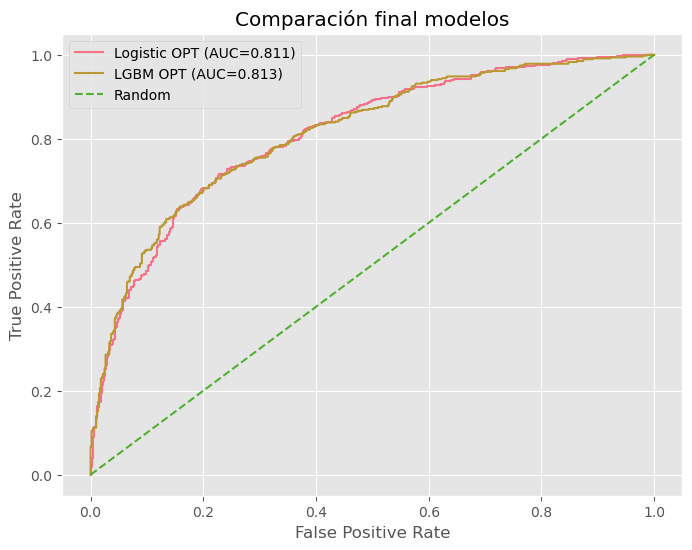

In [55]:
fpr_log, tpr_log, _ = roc_curve(y_test_opt, y_prob_log_opt)
fpr_lgb, tpr_lgb, _ = roc_curve(y_test_opt, y_prob_lgbm_optuna)

plt.figure(figsize=(8,6))

plt.plot(fpr_log, tpr_log, label=f"Logistic OPT (AUC={roc_auc_score(y_test_opt, y_prob_log_opt):.3f})")
plt.plot(fpr_lgb, tpr_lgb, label=f"LGBM OPT (AUC={roc_auc_score(y_test_opt, y_prob_lgbm_optuna):.3f})")

plt.plot([0,1], [0,1], "--", label="Random")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Comparación final modelos")
plt.legend()
plt.show()

### ***Conclusión final***

Tras haber comprobado y diferenciado los resultados de cada modelo con Optuna, me decantaré por utilizar LGBM Optuna con las nuevas features, ya que logra mejorar en general todo el clasification report y da como resultado una mejor CURVA ROC, todo con el fin de poder identificar mejor la probabilidad de recompra de un cliente a nivel de negocio.

---

# ***10 .Scoring de todos los clientes y aplicación del modelo a uso real***

In [56]:
# Dataset completo para scoring
df_scoring = df_model_opt.copy()

# Eliminamos target
X_all_lgbm = df_scoring.drop(columns=["target"])

# Probabilidad de recompra con el modelo final
df_scoring["prob_recompra"] = best_lgbm_optuna.predict_proba(X_all_lgbm)[:, 1]

# Segmentación equilibrada (cuantiles)
df_scoring["segment_q"] = pd.qcut(
    df_scoring["prob_recompra"],
    q=3,
    labels=["Low", "Medium", "High"]
)

# Segmentación basada en negocio (umbrales fijos)
df_scoring["segment_business"] = pd.cut(
    df_scoring["prob_recompra"],
    bins=[0, 0.3, 0.7, 1],
    labels=["Low", "Medium", "High"]
)

display(df_scoring.head())
display(df_scoring["segment_q"].value_counts())
display(df_scoring["segment_business"].value_counts())

,frequency,monetary,total_quantity,n_products,n_returns,recency,customer_age_days,active_months,main_country,avg_ticket_real,max_ticket,avg_distinct_products_per_invoice,avg_days_between_purchases,return_rate,target,prob_recompra,segment_q,segment_business
customer_id,,,,,,,,,,,,,,,,,,
12346,17,-51.74,74285,30,13,234,634,6,United Kingdom,-3.043529,77183.60,2.294118,24.562500,0.764706,0,0.192309,Low,Low
12347,6,3402.39,2099,107,0,38,312,6,Iceland,567.065000,711.79,27.333333,54.400000,0.000000,1,0.822432,High,High
12348,4,1709.40,2497,25,0,157,346,4,Finland,427.350000,892.80,11.000000,63.000000,0.000000,1,0.422100,Medium,Medium
12349,4,2646.99,993,92,5,316,643,4,Italy,661.747500,1402.62,26.750000,108.666667,1.250000,1,0.456773,Medium,Medium
12350,1,334.40,197,17,0,218,218,1,Norway,334.400000,334.40,17.000000,0.000000,0.000000,0,0.175700,Low,Low


segment_q
Low       1781
High      1781
Medium    1780
Name: count, dtype: int64

segment_business
Medium    2390
Low       1936
High      1016
Name: count, dtype: int64

In [57]:
# Hacemos una primera comprobación visual
df_scoring.head(10)

,frequency,monetary,total_quantity,n_products,n_returns,recency,customer_age_days,active_months,main_country,avg_ticket_real,max_ticket,avg_distinct_products_per_invoice,avg_days_between_purchases,return_rate,target,prob_recompra,segment_q,segment_business
customer_id,,,,,,,,,,,,,,,,,,
12346,17,-51.74,74285,30,13,234,634,6,United Kingdom,-3.043529,77183.60,2.294118,24.562500,0.764706,0,0.192309,Low,Low
12347,6,3402.39,2099,107,0,38,312,6,Iceland,567.065000,711.79,27.333333,54.400000,0.000000,1,0.822432,High,High
12348,4,1709.40,2497,25,0,157,346,4,Finland,427.350000,892.80,11.000000,63.000000,0.000000,1,0.422100,Medium,Medium
12349,4,2646.99,993,92,5,316,643,4,Italy,661.747500,1402.62,26.750000,108.666667,1.250000,1,0.456773,Medium,Medium
12350,1,334.40,197,17,0,218,218,1,Norway,334.400000,334.40,17.000000,0.000000,0.000000,0,0.175700,Low,Low
12351,1,300.93,261,21,0,283,283,1,Unspecified,300.930000,300.93,21.000000,0.000000,0.000000,0,0.201191,Low,Low
12352,10,944.98,442,38,10,170,301,3,Norway,94.498000,840.30,6.300000,14.333333,1.000000,1,0.339071,Medium,Medium
12353,2,406.76,212,23,0,112,316,2,Bahrain,203.380000,317.76,12.000000,204.000000,0.000000,0,0.382815,Medium,Medium
12354,1,1079.40,530,58,0,140,140,1,Spain,1079.400000,1079.40,58.000000,0.000000,0.000000,0,0.404142,Medium,Medium


In [58]:
display(df_scoring[df_scoring["segment_q"] == "High"])
display(df_scoring[df_scoring["segment_business"] == "High"])

,frequency,monetary,total_quantity,n_products,n_returns,recency,customer_age_days,active_months,main_country,avg_ticket_real,max_ticket,avg_distinct_products_per_invoice,avg_days_between_purchases,return_rate,target,prob_recompra,segment_q,segment_business
customer_id,,,,,,,,,,,,,,,,,,
12347,6,3402.39,2099,107,0,38,312,6,Iceland,567.065000,711.79,27.333333,54.400000,0.000000,1,0.822432,High,High
12356,5,6313.38,3411,104,0,154,333,4,Portugal,1262.676000,2301.96,27.800000,44.250000,0.000000,1,0.711397,High,High
12359,12,5929.29,2095,230,6,98,642,9,Cyprus,494.107500,1838.91,22.166667,49.090909,0.500000,1,0.812678,High,High
12360,8,3169.11,1968,123,1,21,564,6,Austria,396.138750,1083.58,20.500000,77.142857,0.125000,1,0.673521,High,Medium
12362,7,1854.55,989,89,5,21,647,5,Belgium,264.935714,495.24,15.857143,104.000000,0.714286,1,0.565592,High,Medium
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
18263,2,811.40,1048,45,0,64,161,2,United Kingdom,405.700000,503.80,22.500000,96.000000,0.000000,1,0.549294,High,Medium
18268,8,1451.22,711,36,4,42,637,5,United Kingdom,181.402500,486.64,8.875000,84.428571,0.500000,0,0.565913,High,Medium
18272,9,3375.20,2295,123,6,22,553,8,United Kingdom,375.022222,753.66,20.000000,66.125000,0.666667,1,0.751111,High,High


,frequency,monetary,total_quantity,n_products,n_returns,recency,customer_age_days,active_months,main_country,avg_ticket_real,max_ticket,avg_distinct_products_per_invoice,avg_days_between_purchases,return_rate,target,prob_recompra,segment_q,segment_business
customer_id,,,,,,,,,,,,,,,,,,
12347,6,3402.39,2099,107,0,38,312,6,Iceland,567.065000,711.79,27.333333,54.400000,0.000000,1,0.822432,High,High
12356,5,6313.38,3411,104,0,154,333,4,Portugal,1262.676000,2301.96,27.800000,44.250000,0.000000,1,0.711397,High,High
12359,12,5929.29,2095,230,6,98,642,9,Cyprus,494.107500,1838.91,22.166667,49.090909,0.500000,1,0.812678,High,High
12364,1,623.92,555,34,0,20,20,1,Belgium,623.920000,623.92,34.000000,0.000000,0.000000,1,0.718294,High,High
12380,11,5774.99,2521,125,5,94,571,6,Belgium,524.999091,1765.95,19.454545,47.400000,0.454545,1,0.835494,High,High
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
18245,22,5341.98,4638,291,5,57,549,12,United Kingdom,242.817273,560.23,18.545455,22.952381,0.227273,1,0.852491,High,High
18257,15,3722.04,2049,191,12,22,567,11,United Kingdom,248.136000,1004.37,16.600000,38.428571,0.800000,1,0.885264,High,High
18260,32,9737.10,5244,212,19,81,632,15,United Kingdom,304.284375,1032.29,13.406250,17.322581,0.593750,0,0.825406,High,High


In [59]:
display(df_scoring[df_scoring["segment_q"] == "Medium"])
display(df_scoring[df_scoring["segment_business"] == "Medium"])

,frequency,monetary,total_quantity,n_products,n_returns,recency,customer_age_days,active_months,main_country,avg_ticket_real,max_ticket,avg_distinct_products_per_invoice,avg_days_between_purchases,return_rate,target,prob_recompra,segment_q,segment_business
customer_id,,,,,,,,,,,,,,,,,,
12348,4,1709.40,2497,25,0,157,346,4,Finland,427.350000,892.80,11.000000,63.000000,0.000000,1,0.422100,Medium,Medium
12349,4,2646.99,993,92,5,316,643,4,Italy,661.747500,1402.62,26.750000,108.666667,1.250000,1,0.456773,Medium,Medium
12352,10,944.98,442,38,10,170,301,3,Norway,94.498000,840.30,6.300000,14.333333,1.000000,1,0.339071,Medium,Medium
12353,2,406.76,212,23,0,112,316,2,Bahrain,203.380000,317.76,12.000000,204.000000,0.000000,0,0.382815,Medium,Medium
12354,1,1079.40,530,58,0,140,140,1,Spain,1079.400000,1079.40,58.000000,0.000000,0.000000,0,0.404142,Medium,Medium
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
18273,3,306.00,120,1,0,4,499,3,United Kingdom,102.000000,153.00,1.000000,247.000000,0.000000,1,0.429692,Medium,Medium
18276,7,1297.31,1060,69,3,294,637,5,United Kingdom,185.330000,330.83,11.857143,56.666667,0.428571,1,0.468605,Medium,Medium
18277,7,1001.00,381,49,4,227,403,4,United Kingdom,143.000000,429.32,8.571429,29.166667,0.571429,1,0.389325,Medium,Medium


,frequency,monetary,total_quantity,n_products,n_returns,recency,customer_age_days,active_months,main_country,avg_ticket_real,max_ticket,avg_distinct_products_per_invoice,avg_days_between_purchases,return_rate,target,prob_recompra,segment_q,segment_business
customer_id,,,,,,,,,,,,,,,,,,
12348,4,1709.40,2497,25,0,157,346,4,Finland,427.350000,892.80,11.000000,63.000000,0.000000,1,0.422100,Medium,Medium
12349,4,2646.99,993,92,5,316,643,4,Italy,661.747500,1402.62,26.750000,108.666667,1.250000,1,0.456773,Medium,Medium
12352,10,944.98,442,38,10,170,301,3,Norway,94.498000,840.30,6.300000,14.333333,1.000000,1,0.339071,Medium,Medium
12353,2,406.76,212,23,0,112,316,2,Bahrain,203.380000,317.76,12.000000,204.000000,0.000000,0,0.382815,Medium,Medium
12354,1,1079.40,530,58,0,140,140,1,Spain,1079.400000,1079.40,58.000000,0.000000,0.000000,0,0.404142,Medium,Medium
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
18276,7,1297.31,1060,69,3,294,637,5,United Kingdom,185.330000,330.83,11.857143,56.666667,0.428571,1,0.468605,Medium,Medium
18277,7,1001.00,381,49,4,227,403,4,United Kingdom,143.000000,429.32,8.571429,29.166667,0.571429,1,0.389325,Medium,Medium
18280,3,472.45,194,28,2,186,302,2,United Kingdom,157.483333,307.55,10.666667,57.500000,0.666667,0,0.378100,Medium,Medium


In [60]:
display(df_scoring[df_scoring["segment_q"] == "Low"])
display(df_scoring[df_scoring["segment_q"] == "Low"])

,frequency,monetary,total_quantity,n_products,n_returns,recency,customer_age_days,active_months,main_country,avg_ticket_real,max_ticket,avg_distinct_products_per_invoice,avg_days_between_purchases,return_rate,target,prob_recompra,segment_q,segment_business
customer_id,,,,,,,,,,,,,,,,,,
12346,17,-51.74,74285,30,13,234,634,6,United Kingdom,-3.043529,77183.60,2.294118,24.5625,0.764706,0,0.192309,Low,Low
12350,1,334.40,197,17,0,218,218,1,Norway,334.400000,334.40,17.000000,0.0000,0.000000,0,0.175700,Low,Low
12351,1,300.93,261,21,0,283,283,1,Unspecified,300.930000,300.93,21.000000,0.0000,0.000000,0,0.201191,Low,Low
12355,2,947.61,543,35,0,122,476,2,Bahrain,473.805000,488.21,17.500000,353.0000,0.000000,0,0.125488,Low,Low
12365,3,320.69,174,22,1,199,199,1,Cyprus,106.896667,320.69,7.666667,0.0000,0.333333,0,0.189689,Low,Low
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
18279,1,231.34,630,13,0,427,427,1,United Kingdom,231.340000,231.34,13.000000,0.0000,0.000000,0,0.132791,Low,Low
18281,2,201.14,146,17,0,89,486,2,United Kingdom,100.570000,120.32,8.500000,397.0000,0.000000,0,0.159207,Low,Low
18284,2,436.68,494,28,1,338,340,1,United Kingdom,218.340000,461.68,14.500000,2.0000,0.500000,0,0.259305,Low,Low


,frequency,monetary,total_quantity,n_products,n_returns,recency,customer_age_days,active_months,main_country,avg_ticket_real,max_ticket,avg_distinct_products_per_invoice,avg_days_between_purchases,return_rate,target,prob_recompra,segment_q,segment_business
customer_id,,,,,,,,,,,,,,,,,,
12346,17,-51.74,74285,30,13,234,634,6,United Kingdom,-3.043529,77183.60,2.294118,24.5625,0.764706,0,0.192309,Low,Low
12350,1,334.40,197,17,0,218,218,1,Norway,334.400000,334.40,17.000000,0.0000,0.000000,0,0.175700,Low,Low
12351,1,300.93,261,21,0,283,283,1,Unspecified,300.930000,300.93,21.000000,0.0000,0.000000,0,0.201191,Low,Low
12355,2,947.61,543,35,0,122,476,2,Bahrain,473.805000,488.21,17.500000,353.0000,0.000000,0,0.125488,Low,Low
12365,3,320.69,174,22,1,199,199,1,Cyprus,106.896667,320.69,7.666667,0.0000,0.333333,0,0.189689,Low,Low
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
18279,1,231.34,630,13,0,427,427,1,United Kingdom,231.340000,231.34,13.000000,0.0000,0.000000,0,0.132791,Low,Low
18281,2,201.14,146,17,0,89,486,2,United Kingdom,100.570000,120.32,8.500000,397.0000,0.000000,0,0.159207,Low,Low
18284,2,436.68,494,28,1,338,340,1,United Kingdom,218.340000,461.68,14.500000,2.0000,0.500000,0,0.259305,Low,Low


## ***11. Modelo: explicabilidad***
indicar las variables más relevantes del modelo. COn Dalex o más sencillo, los propios  tiene manera de obtener las variables:   
Ej. 

from xgboost import plot_importance
import matplotlib.pyplot as plt

plot_importance(model)
plt.show()



In [61]:
importance_lgbm = pd.DataFrame({
    "feature": X_train_opt.columns,
    "importance": best_lgbm_optuna.feature_importances_
})

# Ordenamos las variables de mayor a menor importancia
importance_lgbm = importance_lgbm.sort_values("importance", ascending=False)

# Mostramos las variables más relevantes
display(importance_lgbm.head(10))

,feature,importance
5,recency,455
12,avg_days_between_purchases,337
1,monetary,231
6,customer_age_days,224
9,avg_ticket_real,188
7,active_months,180
10,max_ticket,152
2,total_quantity,151
11,avg_distinct_products_per_invoice,141
0,frequency,134


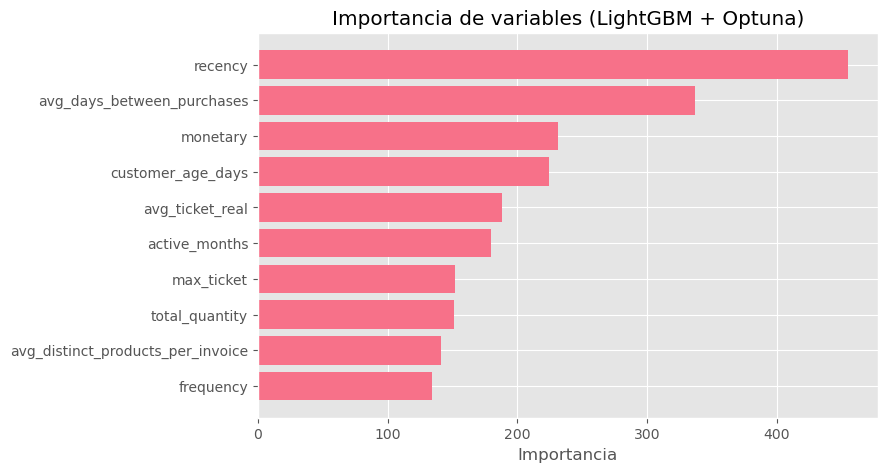

In [62]:
plt.figure(figsize=(8,5))
plt.barh(importance_lgbm["feature"].head(10)[::-1],
         importance_lgbm["importance"].head(10)[::-1])

plt.title("Importancia de variables (LightGBM + Optuna)")
plt.xlabel("Importancia")
plt.show()

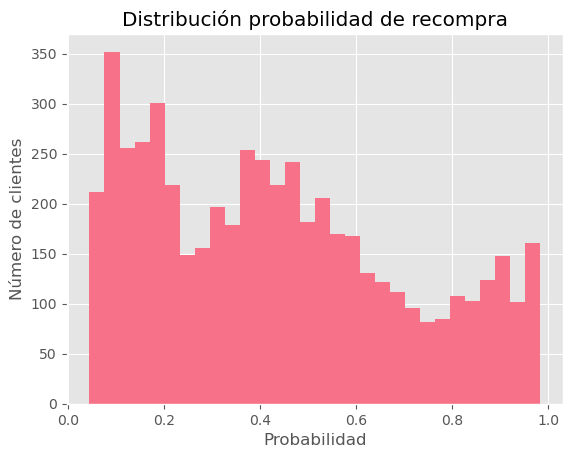

In [63]:
plt.hist(df_scoring["prob_recompra"], bins=30)
plt.title("Distribución probabilidad de recompra")
plt.xlabel("Probabilidad")
plt.ylabel("Número de clientes")
plt.show()

In [64]:
df_scoring["segment_q"].value_counts()

segment_q
Low       1781
High      1781
Medium    1780
Name: count, dtype: int64

In [65]:
df_scoring["segment_business"].value_counts()

segment_business
Medium    2390
Low       1936
High      1016
Name: count, dtype: int64

### ***Interpretación del modelo y segmentación***

Se analiza la importancia de las variables del modelo de regresión logística para comprender qué factores influyen en la probabilidad de recompra.

Los resultados muestran que las variables más relevantes son:

- **Recency (negativa)**: cuanto más tiempo pasa desde la última compra, menor es la probabilidad de recompra.
- **Frequency (positiva)**: clientes con mayor número de compras tienen mayor probabilidad de volver.
- **Número de productos y gasto total (monetary)**: reflejan el nivel de actividad del cliente y contribuyen positivamente a la recompra.

Por otro lado, variables como el ticket medio o la tasa de devoluciones tienen menor impacto en la predicción.

En cuanto a la distribución de probabilidades, se observa que la mayoría de clientes se concentran en valores intermedios, lo que refleja un comportamiento heterogéneo y no trivial.

Finalmente, se segmenta a los clientes en tres grupos:

### Segmentación de clientes según probabilidad de recompra

A partir de las probabilidades estimadas por el modelo, se segmentan los clientes en distintos grupos:

- **Segmentación por cuantiles (qcut)**: divide a los clientes en grupos de tamaño similar, facilitando el análisis comparativo.
- **Segmentación por umbrales (cut)**: establece rangos fijos de probabilidad, más alineados con decisiones de negocio.

Esto permite identificar clientes con mayor potencial de recompra y definir estrategias diferenciadas de marketing y retención.

---

## ***Ahora con Dalex***

In [66]:
!pip install dalex

In [67]:
import dalex as dx

# Creamos el explainer de DALEX para el modelo final
explainer_lgbm = dx.Explainer(
    model=best_lgbm_optuna,
    data=X_test_opt,
    y=y_test_opt,
    label="LightGBM + Optuna"
)

# 1. Importancia global de variables
vi_lgbm = explainer_lgbm.model_parts()

# Mostramos tabla de resultados
display(vi_lgbm.result.head(10))

# Gráfico de importancia global
vi_lgbm.plot()
plt.show()

Preparation of a new explainer is initiated

  -> data              : 1069 rows 14 cols
  -> target variable   : Parameter 'y' was a pandas.Series. Converted to a numpy.ndarray.
  -> target variable   : 1069 values
  -> model_class       : lightgbm.sklearn.LGBMClassifier (default)
  -> label             : LightGBM + Optuna
  -> predict function  : <function yhat_proba_default at 0x0000018184FFF1A0> will be used (default)
  -> predict function  : Accepts only pandas.DataFrame, numpy.ndarray causes problems.
  -> predicted values  : min = 0.0497, mean = 0.433, max = 0.979
  -> model type        : classification will be used (default)
  -> residual function : difference between y and yhat (default)
  -> residuals         : min = -0.952, mean = 0.00213, max = 0.942
  -> model_info        : package lightgbm

A new explainer has been created!


,variable,dropout_loss,label
0,main_country,0.183769,LightGBM + Optuna
1,avg_ticket_real,0.184081,LightGBM + Optuna
2,total_quantity,0.184245,LightGBM + Optuna
3,n_returns,0.184504,LightGBM + Optuna
4,_full_model_,0.184600,LightGBM + Optuna
5,return_rate,0.185034,LightGBM + Optuna
6,avg_distinct_products_per_invoice,0.185492,LightGBM + Optuna
7,max_ticket,0.185875,LightGBM + Optuna
8,active_months,0.187755,LightGBM + Optuna
9,n_products,0.188146,LightGBM + Optuna


### ***Explicabilidad global con DALEX***
#### ***Interpretación de la importancia de variables***

-   El análisis de importancia de variables mediante DALEX muestra que la variable más relevante es **recency**, lo cual indica que el tiempo transcurrido desde la última compra es el factor más determinante en la probabilidad de recompra.
-   Este resultado es coherente con modelos clásicos de comportamiento del cliente (RFM), donde la recencia es un predictor clave.

Además, variables temporales como el tiempo medio entre compras (`avg_days_between_purchases`) y la antigüedad del cliente (`customer_age_days`) también presentan una alta relevancia, lo que indica que el modelo captura correctamente la dinámica temporal del comportamiento de compra.
-   Por otro lado, variables relacionadas con el gasto (`monetary`, `avg_ticket_real`, `max_ticket`) y la actividad (`frequency`, `n_products`) también contribuyen a la predicción, aunque con menor impacto relativo.
-   La consistencia de estos resultados entre distintos modelos (LightGBM y regresión logística) refuerza la robustez de los patrones identificados.

---

In [68]:
# Top 10 clientes más probables de recompra
top_clients = df_scoring.sort_values("prob_recompra", ascending=False).head(10)
display(top_clients)

,frequency,monetary,total_quantity,n_products,n_returns,recency,customer_age_days,active_months,main_country,avg_ticket_real,max_ticket,avg_distinct_products_per_invoice,avg_days_between_purchases,return_rate,target,prob_recompra,segment_q,segment_business
customer_id,,,,,,,,,,,,,,,,,,
17696,46,7017.72,5458,187,34,0,637,18,United Kingdom,152.559130,667.65,8.217391,13.755556,0.739130,1,0.983981,High,High
12709,47,27053.25,12691,190,79,3,638,21,Germany,575.601064,3857.20,10.659574,13.326087,1.680851,1,0.983421,High,High
16011,26,4420.26,2707,169,2,0,647,17,United Kingdom,170.010000,299.25,14.192308,25.400000,0.076923,1,0.982019,High,High
12839,25,7035.69,4842,139,9,0,641,17,United Kingdom,281.427600,593.08,17.200000,26.250000,0.360000,1,0.981511,High,High
15005,67,11640.36,7456,527,87,4,646,22,United Kingdom,173.736716,407.24,31.865672,9.348485,1.298507,1,0.981273,High,High
12540,29,17979.41,8767,301,2,0,640,20,Spain,619.979655,1380.11,21.241379,22.321429,0.068966,1,0.981213,High,High
17841,232,50240.40,26438,1943,153,0,645,22,United Kingdom,216.553448,979.05,39.577586,2.415584,0.659483,1,0.980921,High,High
13267,44,7818.71,3334,135,20,0,640,18,United Kingdom,177.697955,440.82,8.363636,14.488372,0.454545,1,0.980583,High,High
17865,53,22133.22,10726,354,40,0,647,21,United Kingdom,417.607925,1563.65,17.490566,12.153846,0.754717,1,0.980562,High,High


# ***Conclusiones finales e insights del proyecto***

A lo largo del proyecto se ha desarrollado un modelo de machine learning orientado a predecir la probabilidad de recompra de clientes a partir de su histórico de transacciones.

### ***Calidad y preparación de los datos***

El dataset presenta un volumen elevado de registros y una estructura transaccional típica del entorno retail. Durante el proceso de limpieza se han identificado varios aspectos relevantes:

- Existencia de devoluciones/cancelaciones (cantidades negativas), que se han mantenido por su valor informativo.
- Presencia de clientes sin identificador, los cuales han sido eliminados adecuadamente.
- Distribuciones altamente sesgadas en variables como cantidad y precio, con presencia de outliers significativos.
- Fuerte concentración geográfica en un único país (United Kingdom).

Se ha realizado un proceso de feature engineering adecuado, generando variables agregadas por cliente que capturan su comportamiento histórico.

---

### ***Modelado y rendimiento***

Se ha planteado un enfoque supervisado utilizando una separación temporal (cutoff) para evitar fuga de información:

- Datos históricos → construcción de variables (df_past)  
- Datos futuros → construcción del target (df_future)

Se han probado distintos modelos:

- Regresión logística  
- Random Forest  
- XGBoost  
- LightGBM  

El modelo que ha mostrado mejor rendimiento ha sido la **regresión logística**, con un ROC-AUC cercano a **0.808**, lo que indica una buena capacidad de discriminación entre clientes que recompran y los que no.

---

### ***Variables clave del comportamiento del cliente***

El análisis de explicabilidad (coeficientes y DALEX) ha permitido identificar los factores más relevantes:

- **Recency** (tiempo desde la última compra): principal variable, con impacto negativo  
- **Frequency** (número de compras): impacto positivo  
- **Número de productos distintos**: indicador de actividad  
- **Monetary (gasto total)**: contribución positiva  

---

### ***Segmentación de clientes***

A partir de la probabilidad de recompra estimada, se ha realizado una segmentación en tres grupos:

- **High**: clientes con alta probabilidad de recompra  
- **Medium**: clientes con potencial  
- **Low**: clientes con bajo engagement  

La distribución de clientes entre segmentos es equilibrada, lo que indica que el modelo es capaz de discriminar adecuadamente entre distintos perfiles.

---

### ***Insights de negocio***

A partir del análisis realizado, se pueden extraer las siguientes conclusiones:

- Los clientes recientes y frecuentes tienen una probabilidad significativamente mayor de volver a comprar.
- El tiempo desde la última compra es el factor más determinante del comportamiento futuro.
- Los clientes con mayor diversidad de productos presentan mayor fidelización.
- El gasto total influye, pero no es el principal

---

### ***Aplicaciones prácticas***

Este modelo permite:

- Identificar clientes con riesgo de no recompra (segmento Low) para campañas de retención.
- Priorizar clientes con alto potencial (segmento Medium) mediante acciones comerciales específicas.
- Optimizar recursos focalizando esfuerzos en los clientes con mayor probabilidad de conversión.
- Diseñar estrategias de fidelización basadas en comportamiento real del cliente.

---

### ***Conclusión final***

El modelo desarrollado es capaz de capturar patrones relevantes del comportamiento del cliente y proporciona una herramienta útil para la toma de decisiones en el ámbito del marketing y la gestión de clientes.

Además, su interpretabilidad permite comprender claramente los factores que influyen en la recompra, lo que facilita su aplicación en entornos reales de negocio.

# ***Visualizaciones más importantes***

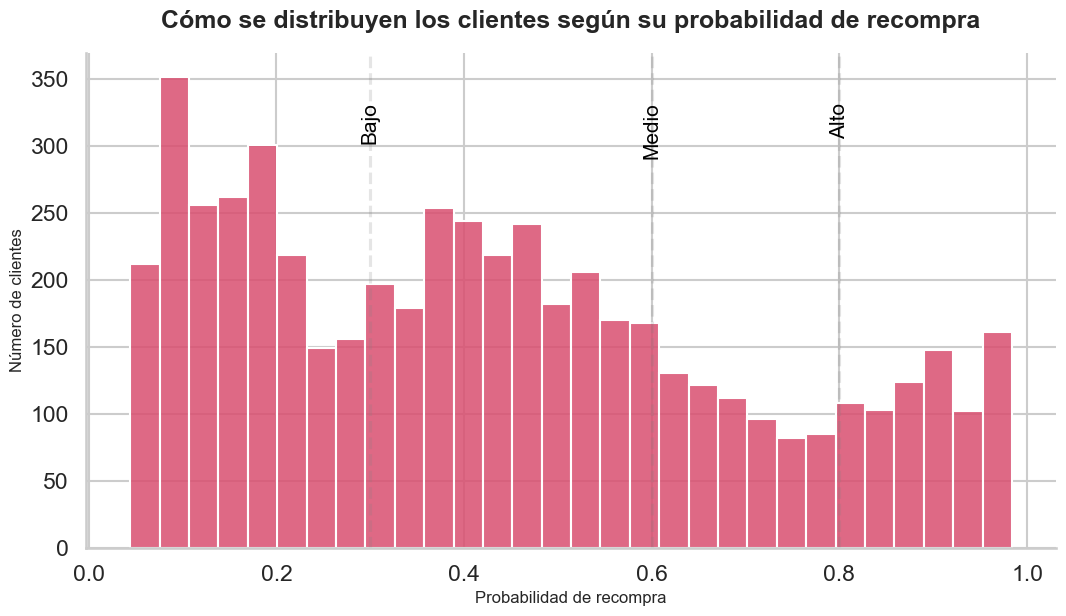

In [103]:
sns.set_theme(style="whitegrid", context="talk")

fig, ax = plt.subplots(figsize=(11, 6.5))

# Histograma
sns.histplot(
    df_scoring["prob_recompra"],
    bins=30,
    color="#D94F70",
    alpha=0.85,
    edgecolor="white",
    ax=ax
)

# Líneas de referencia (segmentación negocio)
for x, label in [(0.3, "Bajo"), (0.6, "Medio"), (0.8, "Alto")]:
    ax.axvline(x, linestyle="--", color="gray", alpha=0.2)
    ax.text(x, ax.get_ylim()[1]*0.9, label,
            rotation=90, va="top", ha="center", fontsize=15, color="black", alpha=1)

# Títulos
ax.set_title("Cómo se distribuyen los clientes según su probabilidad de recompra",
             fontsize=18, weight="bold", pad=18)

# Ejes
ax.set_xlabel("Probabilidad de recompra", fontsize=12)
ax.set_ylabel("Número de clientes", fontsize=12)

# Limpieza visual
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

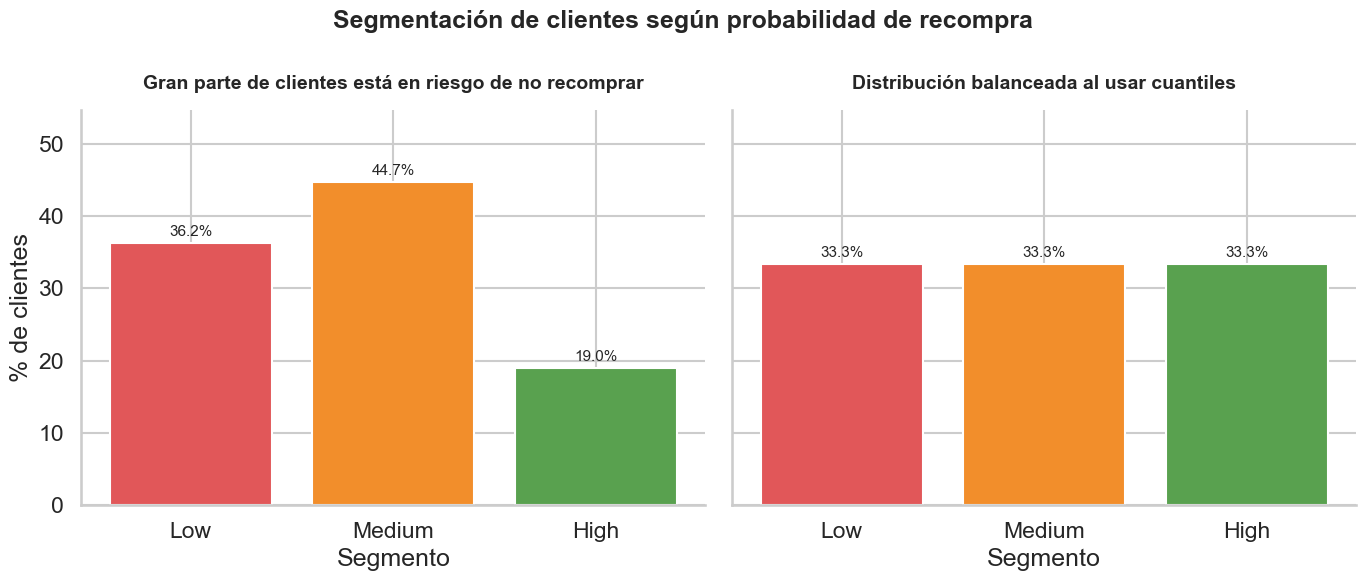

In [105]:
sns.set_theme(style="whitegrid", context="talk")

# ---- Preparar datos en % ----
seg_business = (
    df_scoring["segment_business"]
    .value_counts(normalize=True)
    .reindex(["Low", "Medium", "High"])
    .mul(100)
)

seg_quantiles = (
    df_scoring["segment_q"]
    .value_counts(normalize=True)
    .reindex(["Low", "Medium", "High"])
    .mul(100)
)

# ---- Colores semánticos ----
colors = ["#E15759", "#F28E2B", "#59A14F"]  # rojo, naranja, verde

# ---- Crear figura ----
fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)

# =========================
# Gráfico 1: Negocio
# =========================
ax = axes[0]
bars = ax.bar(seg_business.index, seg_business.values, color=colors)

ax.set_title(
    "Gran parte de clientes está en riesgo de no recomprar",
    fontsize=14,
    weight="bold",
    pad=15
)
ax.set_xlabel("Segmento")
ax.set_ylabel("% de clientes")

# Etiquetas encima de barras
for i, v in enumerate(seg_business.values):
    ax.text(i, v + 1, f"{v:.1f}%", ha='center', fontsize=11)

# =========================
# Gráfico 2: Cuantiles
# =========================
ax = axes[1]
bars = ax.bar(seg_quantiles.index, seg_quantiles.values, color=colors)

ax.set_title(
    "Distribución balanceada al usar cuantiles",
    fontsize=14,
    weight="bold",
    pad=15
)
ax.set_xlabel("Segmento")

# Etiquetas encima de barras
for i, v in enumerate(seg_quantiles.values):
    ax.text(i, v + 1, f"{v:.1f}%", ha='center', fontsize=11)

# ---- Limpieza visual ----
for ax in axes:
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.set_ylim(0, max(seg_business.max(), seg_quantiles.max()) + 10)

# ---- Título general ----
fig.suptitle(
    "Segmentación de clientes según probabilidad de recompra",
    fontsize=18,
    weight="bold"
)

plt.tight_layout()
plt.show()

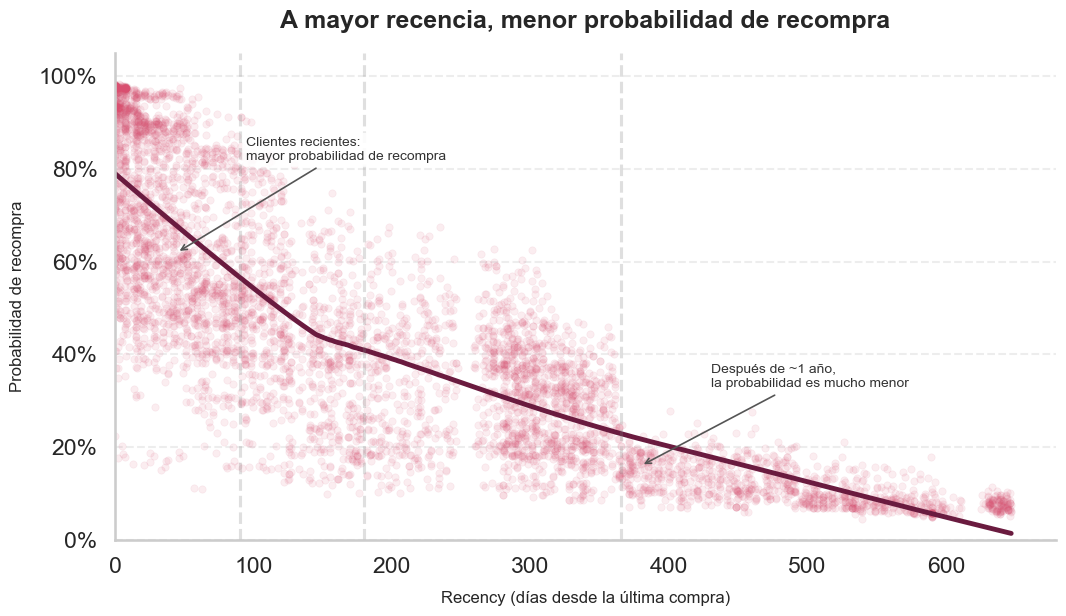

In [94]:
from matplotlib.ticker import PercentFormatter

# Estilo general
sns.set_theme(style="whitegrid", context="talk")

fig, ax = plt.subplots(figsize=(11, 6.5))

# Scatter suave para que no opaque la tendencia
sns.scatterplot(
    data=df_scoring,
    x="recency",
    y="prob_recompra",
    alpha=0.10,
    s=28,
    color="#D94F70",
    edgecolor=None,
    ax=ax
)

# Línea LOWESS destacada
sns.regplot(
    data=df_scoring,
    x="recency",
    y="prob_recompra",
    scatter=False,
    lowess=True,
    line_kws={"color": "#6A1B3F", "lw": 3.5},
    ax=ax
)

# Títulos
ax.set_title("A mayor recencia, menor probabilidad de recompra",
             fontsize=18, weight="bold", pad=18)


# Ejes
ax.set_xlabel("Recency (días desde la última compra)", fontsize=12, labelpad=10)
ax.set_ylabel("Probabilidad de recompra", fontsize=12, labelpad=10)
ax.yaxis.set_major_formatter(PercentFormatter(1.0))

# Límites y limpieza visual
ax.set_ylim(0, 1.05)
ax.set_xlim(left=0)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.grid(True, axis="y", linestyle="--", alpha=0.35)
ax.grid(False, axis="x")

# Líneas de referencia por tramos
for x in [90, 180, 365]:
    ax.axvline(x, linestyle="--", color="gray", alpha=0.25)

# Anotaciones de negocio
ax.annotate(
    "Clientes recientes:\nmayor probabilidad de recompra",
    xy=(45, 0.62), xytext=(95, 0.82),
    arrowprops=dict(arrowstyle="->", color="#555555", lw=1.2),
    fontsize=10, color="#333333",
    bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="none", alpha=0.9)
)

ax.annotate(
    "Después de ~1 año,\nla probabilidad es mucho menor",
    xy=(380, 0.16), xytext=(430, 0.33),
    arrowprops=dict(arrowstyle="->", color="#555555", lw=1.2),
    fontsize=10, color="#333333",
    bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="none", alpha=0.9)
)

plt.tight_layout()
plt.show()

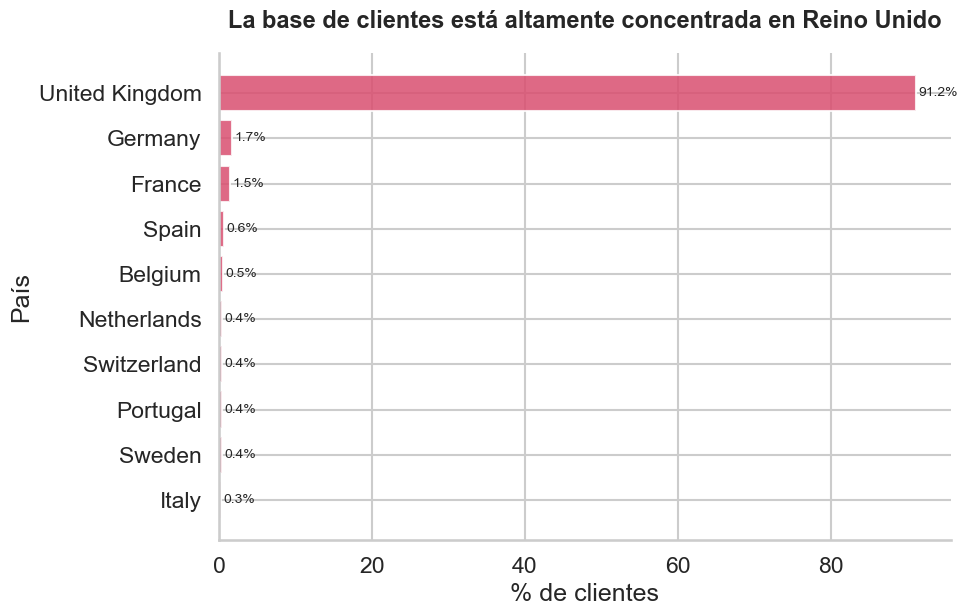

In [117]:
sns.set_theme(style="whitegrid", context="talk")

# Top 10 países en porcentaje
country_pct = (
    df_scoring["main_country"]
    .value_counts(normalize=True)
    .head(10)
    .sort_values()
    .mul(100)
)

fig, ax = plt.subplots(figsize=(10, 6.5))

bars = ax.barh(country_pct.index, country_pct.values, color="#D94F70", alpha=0.85)

ax.set_title(
    "La base de clientes está altamente concentrada en Reino Unido",
    fontsize=17,
    weight="bold",
    pad=18
)

ax.set_xlabel("% de clientes")
ax.set_ylabel("País")

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# Etiquetas al final de cada barra
for i, v in enumerate(country_pct.values):
    ax.text(v + 0.3, i, f"{v:.1f}%", va="center", fontsize=10)

plt.tight_layout()
plt.show()

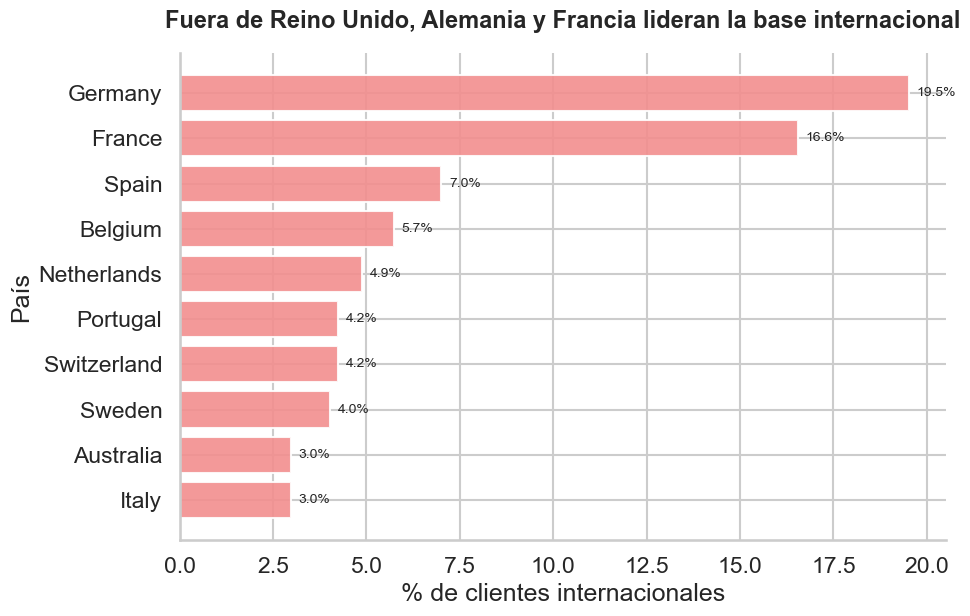

In [116]:
sns.set_theme(style="whitegrid", context="talk")

country_no_uk = (
    df_scoring.loc[df_scoring["main_country"] != "United Kingdom", "main_country"]
    .value_counts(normalize=True)
    .head(10)
    .sort_values()
    .mul(100)
)

fig, ax = plt.subplots(figsize=(10, 6.5))

ax.barh(country_no_uk.index, country_no_uk.values, color="#F28E8E", alpha=0.9)

ax.set_title(
    "Fuera de Reino Unido, Alemania y Francia lideran la base internacional",
    fontsize=17,
    weight="bold",
    pad=18
)

ax.set_xlabel("% de clientes internacionales")
ax.set_ylabel("País")

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

for i, v in enumerate(country_no_uk.values):
    ax.text(v + 0.2, i, f"{v:.1f}%", va="center", fontsize=10)

plt.tight_layout()
plt.show()

In [114]:
segment_profile_clean = (
    segment_profile
    .rename(columns={
        "frequency": "Frecuencia Media",
        "monetary": "Gasto total Medio",
        "recency": "Media de Días desde última compra",
        "avg_ticket_real": "Ticket medio"
    })
    .copy()
)

# Formato
segment_profile_clean["Frecuencia Media"] = segment_profile_clean["Frecuencia Media"].round(1)
segment_profile_clean["Gasto total Medio"] = segment_profile_clean["Gasto total Medio"].map(lambda x: f"{x:,.0f}")
segment_profile_clean["Media de Días desde última compra"] = segment_profile_clean["Media de Días desde última compra"].round(0).astype(int)
segment_profile_clean["Ticket medio"] = segment_profile_clean["Ticket medio"].map(lambda x: f"{x:,.0f}")

display(segment_profile_clean)

,Frecuencia Media,Gasto total Medio,Media de Días desde última compra,Ticket medio
segment_business,,,,
Low,1.9,382,376,212
Medium,4.9,"1,383",146,299
High,21.3,"8,928",32,380


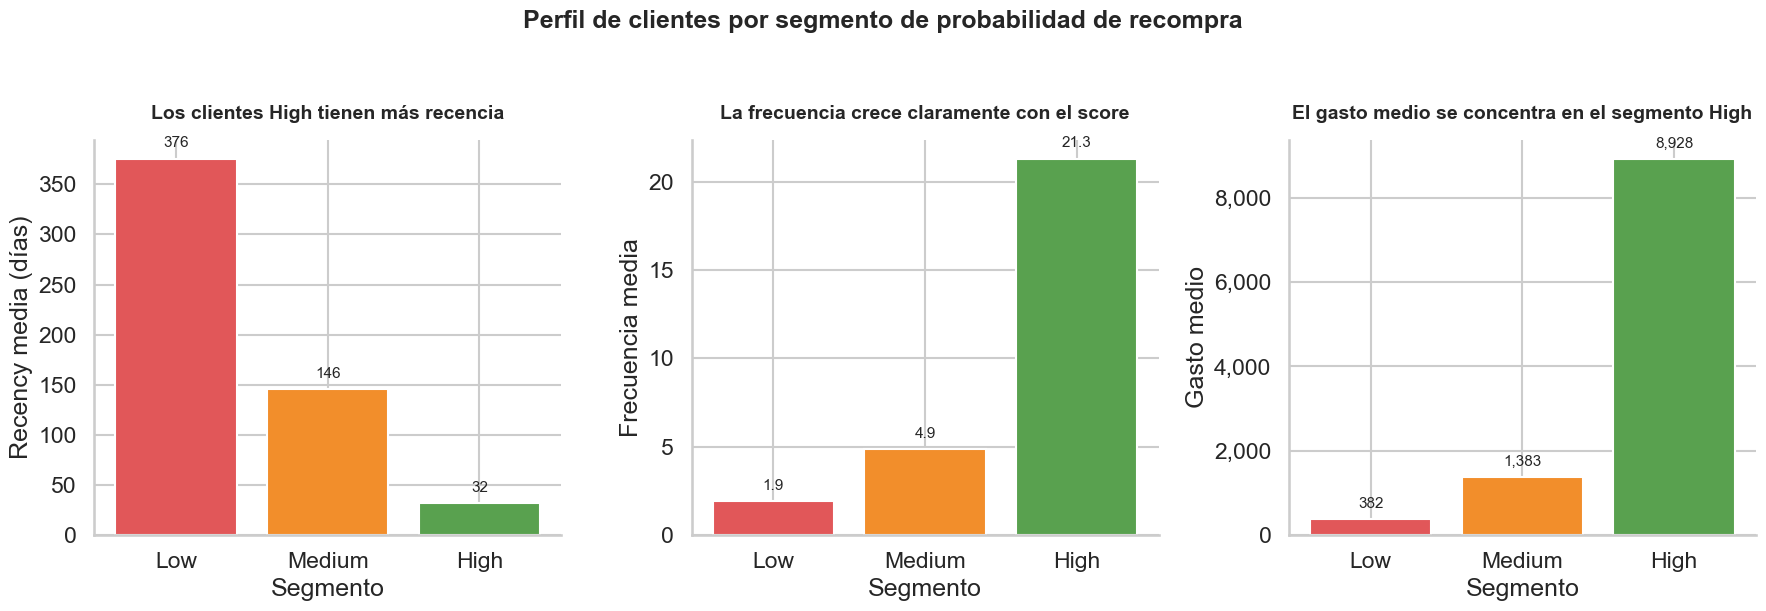

In [107]:
from matplotlib.ticker import FuncFormatter

# Estilo general
sns.set_theme(style="whitegrid", context="talk")

# Orden fijo de segmentos
order = ["Low", "Medium", "High"]

# Reordenar datos
profile_plot = segment_profile.loc[order, ["recency", "frequency", "monetary"]].copy()

# Colores semánticos
colors = ["#E15759", "#F28E2B", "#59A14F"]  # rojo, naranja, verde

# Formateador de miles
def miles(x, pos):
    return f"{x:,.0f}"

# Crear figura con 3 gráficos
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# =========================
# 1. Recency
# =========================
ax = axes[0]
bars = ax.bar(profile_plot.index, profile_plot["recency"], color=colors)

ax.set_title("Los clientes High tienen más recencia", fontsize=14, weight="bold", pad=15)
ax.set_xlabel("Segmento")
ax.set_ylabel("Recency media (días)")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

for i, v in enumerate(profile_plot["recency"]):
    ax.text(i, v + profile_plot["recency"].max() * 0.03, f"{v:,.0f}", ha="center", fontsize=11)

# =========================
# 2. Frequency
# =========================
ax = axes[1]
bars = ax.bar(profile_plot.index, profile_plot["frequency"], color=colors)

ax.set_title("La frecuencia crece claramente con el score", fontsize=14, weight="bold", pad=15)
ax.set_xlabel("Segmento")
ax.set_ylabel("Frecuencia media")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

for i, v in enumerate(profile_plot["frequency"]):
    ax.text(i, v + profile_plot["frequency"].max() * 0.03, f"{v:,.1f}", ha="center", fontsize=11)

# =========================
# 3. Monetary
# =========================
ax = axes[2]
bars = ax.bar(profile_plot.index, profile_plot["monetary"], color=colors)

ax.set_title("El gasto medio se concentra en el segmento High", fontsize=14, weight="bold", pad=15)
ax.set_xlabel("Segmento")
ax.set_ylabel("Gasto medio")
ax.yaxis.set_major_formatter(FuncFormatter(miles))
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

for i, v in enumerate(profile_plot["monetary"]):
    ax.text(i, v + profile_plot["monetary"].max() * 0.03, f"{v:,.0f}", ha="center", fontsize=11)

# Título general
fig.suptitle(
    "Perfil de clientes por segmento de probabilidad de recompra",
    fontsize=18,
    weight="bold",
    y=1.03
)

plt.tight_layout()
plt.show()

In [108]:
top_clients = (
    df_scoring.sort_values("prob_recompra", ascending=False)
    .head(10)[
        ["prob_recompra", "frequency", "monetary", "recency",
         "avg_ticket_real", "main_country", "segment_business"]
    ]
    .rename(columns={
        "prob_recompra": "Prob. recompra",
        "frequency": "Frecuencia",
        "monetary": "Gasto total",
        "recency": "Recency",
        "avg_ticket_real": "Ticket medio",
        "main_country": "País",
        "segment_business": "Segmento"
    })
)

top_clients["Prob. recompra"] = (top_clients["Prob. recompra"] * 100).round(1).astype(str) + "%"
top_clients["Frecuencia"] = top_clients["Frecuencia"].round(0).astype(int)
top_clients["Gasto total"] = top_clients["Gasto total"].map(lambda x: f"{x:,.0f}")
top_clients["Recency"] = top_clients["Recency"].round(0).astype(int)
top_clients["Ticket medio"] = top_clients["Ticket medio"].map(lambda x: f"{x:,.2f}")

display(top_clients)

,Prob. recompra,Frecuencia,Gasto total,Recency,Ticket medio,País,Segmento
customer_id,,,,,,,
17696,98.4%,46,"7,018",0,152.56,United Kingdom,High
12709,98.3%,47,"27,053",3,575.60,Germany,High
16011,98.2%,26,"4,420",0,170.01,United Kingdom,High
12839,98.2%,25,"7,036",0,281.43,United Kingdom,High
15005,98.1%,67,"11,640",4,173.74,United Kingdom,High
12540,98.1%,29,"17,979",0,619.98,Spain,High
17841,98.1%,232,"50,240",0,216.55,United Kingdom,High
13267,98.1%,44,"7,819",0,177.70,United Kingdom,High
17865,98.1%,53,"22,133",0,417.61,United Kingdom,High


C:\Users\User\AppData\Local\Temp\ipykernel_23412\1850179219.py:17: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.


C:\Users\User\AppData\Local\Temp\ipykernel_23412\1850179219.py:51: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



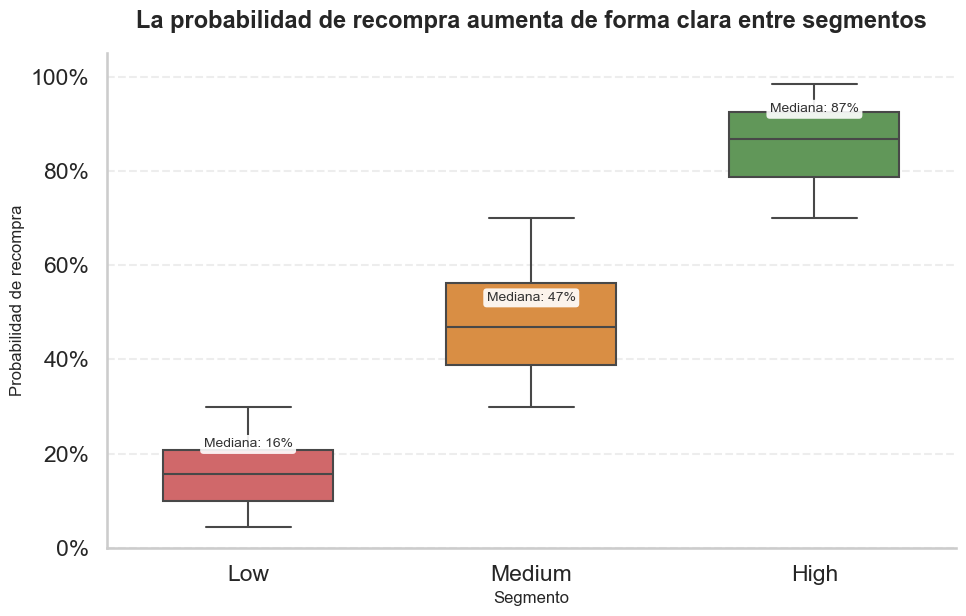

In [110]:
from matplotlib.ticker import PercentFormatter

# Estilo
sns.set_theme(style="whitegrid", context="talk")

# Orden y paleta semántica
order = ["Low", "Medium", "High"]
palette = {
    "Low": "#E15759",
    "Medium": "#F28E2B",
    "High": "#59A14F"
}

fig, ax = plt.subplots(figsize=(10, 6.5))

# Boxplot
sns.boxplot(
    data=df_scoring,
    x="segment_business",
    y="prob_recompra",
    order=order,
    palette=palette,
    width=0.6,
    linewidth=1.5,
    fliersize=2,
    ax=ax
)

# Título y subtítulo
ax.set_title(
    "La probabilidad de recompra aumenta de forma clara entre segmentos",
    fontsize=17,
    weight="bold",
    pad=18
)

# Ejes
ax.set_xlabel("Segmento", fontsize=12)
ax.set_ylabel("Probabilidad de recompra", fontsize=12)
ax.yaxis.set_major_formatter(PercentFormatter(1.0))
ax.set_ylim(0, 1.05)

# Limpieza visual
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.grid(True, axis="y", linestyle="--", alpha=0.35)
ax.grid(False, axis="x")

# Añadir mediana por segmento
medians = (
    df_scoring.groupby("segment_business")["prob_recompra"]
    .median()
    .reindex(order)
)

for i, (segment, value) in enumerate(medians.items()):
    ax.text(
        i, value + 0.05,
        f"Mediana: {value:.0%}",
        ha="center",
        va="bottom",
        fontsize=10,
        color="#333333",
        bbox=dict(boxstyle="round,pad=0.25", fc="white", ec="none", alpha=0.9)
    )

plt.tight_layout()
plt.show()